# Membership Churn Analysis

## Notebook 04: Exploratory Data Analysis Part 1

---

**Author:** D. 
**Date:** March 3, 2026 
**Dataset:** churn_t_db.csv (2.1GB, 18.4M rows)

---

### Dependencies

In [0]:
# ═══════════════════════════════════════════════════════════════
# Dependencies
# ═══════════════════════════════════════════════════════════════

import sys
from datetime import datetime
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType, StringType, DoubleType
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("Dependencies loaded successfully")

Dependencies loaded successfully


## 1.0 Setup & Configuration

### 1.1 Environment Verification

**CONTEXT**

To establish the foundational environment for Exploratory Data Analysis Part 1. This includes verifying Spark availability, confirming access to the Silver table produced in Notebook 02, and validating the cleaned dataset before any exploratory analysis begins.


**PURPOSE**

To ensure:
1. PySpark environment is properly initialised
2. The Silver table is accessible at the expected Unity Catalog volume path
3. Visualisation libraries are confirmed available
4. Confident progression to exploratory analysis

**STEP**

Confirm that the Silver table exists at the expected path and verify PySpark and visualisation library initialisation.

In [0]:
# ═══════════════════════════════════════════════════════════════
# 1.1 Environment Verification
# ═══════════════════════════════════════════════════════════════

# Check Spark version
print(f"Spark Version    : {spark.version}")
print(f"Python Version   : {sys.version}")
print(f"Pandas Version   : {pd.__version__}")
print("-" * 70)

# Verify Silver table exists
file_info = dbutils.fs.ls("/Volumes/workspace/rcn_churn/silver/")
display(file_info)

# Confirm Silver table path
silver_path = "/Volumes/workspace/rcn_churn/silver/churn_cleaned/"
print(f"\nSilver table path: {silver_path}")

Spark Version    : 4.1.0
Python Version   : 3.12.3 (main, Jan  8 2026, 11:30:50) [GCC 13.3.0]
Pandas Version   : 2.2.3
----------------------------------------------------------------------


path,name,size,modificationTime
dbfs:/Volumes/workspace/rcn_churn/silver/churn_cleaned/,churn_cleaned/,0,1773331940703



Silver table path: /Volumes/workspace/rcn_churn/silver/churn_cleaned/


**RESULT**

Spark 4.1.0 is initialised and operational. The Silver table is accessible at `/Volumes/workspace/rcn_churn/silver/churn_cleaned/`. All visualisation libraries, Plotly and Matplotlib/Seaborn, are confirmed available. Environment is validated and ready for exploratory analysis.

**Status:** ✓ Pass

### 1.2 Data Loading

**CONTEXT**

Notebook 04 loads directly from the Silver table produced in Notebook 02 and validated in Notebook 03. All exploratory analysis operates on the fully cleaned and classified dataset, ensuring consistency with the missingness treatments and cleaning flags established in previous notebooks.

**PURPOSE**

To ensure:
1. The Silver table loads successfully with the expected row and column count
2. The 14-column schema from Notebook 02 is preserved and consistent
3. A verified baseline exists before any exploratory analysis begins
4. Confident progression to temporal and distributional analysis

**STEP**

Load the Silver table into a PySpark DataFrame and confirm row count, column count, and schema against the baseline established in Notebook 02.

In [0]:
# ═══════════════════════════════════════════════════════════════
# 1.2 Data Loading
# ═══════════════════════════════════════════════════════════════

# Define Silver table path
silver_path = "/Volumes/workspace/rcn_churn/silver/churn_cleaned/"

# Load Silver table
df = spark.read.format("delta").load(silver_path)

# Confirm row and column count
row_count = df.count()
col_count = len(df.columns)

print(f"Rows    : {row_count:,}")
print(f"Columns : {col_count}")
print("-" * 70)

# Display schema
df.printSchema()

Rows    : 18,461,480
Columns : 14
----------------------------------------------------------------------
root
 |-- _c0: integer (nullable = true)
 |-- CM_snapshot_date: date (nullable = true)
 |-- Int_nurse: string (nullable = true)
 |-- Region: string (nullable = true)
 |-- MemCategory: string (nullable = true)
 |-- CatName: string (nullable = true)
 |-- Branch: string (nullable = true)
 |-- YoB: integer (nullable = true)
 |-- MemSectorType: string (nullable = true)
 |-- YoJ: integer (nullable = true)
 |-- q_members_t: double (nullable = true)
 |-- q_leavers_t: double (nullable = true)
 |-- cleaning_flag: string (nullable = true)
 |-- geo_flag: string (nullable = true)



**RESULT**

The Silver table loaded successfully with 18,461,480 rows and 14 columns, consistent with the baseline established in Notebook 02. The schema is preserved as expected with all cleaning and geo flag columns confirmed present. `YoB` and `YoJ` are correctly stored as `integer` type. The dataset is validated and ready for exploratory analysis.

**Status:** ✓ Pass

### 1.3 Configuration & Constants

**CONTEXT**

To centralise all notebook configuration in a single location, establishing path constants, visualisation settings, and colour palette that will be referenced consistently throughout all exploratory analysis and visualisations in this notebook.


**PURPOSE**

To ensure:
1. All file paths are defined consistently and referenced from a single source
2. Visualisation colour palette is standardised across all charts
3. Chart styling is consistent and professional throughout the notebook
4. Any future changes to configuration require a single update point

**STEP**

Define all path constants, an accessible high-contrast analytical colour palette selected for WCAG compliance and clarity across both interactive and publication-quality outputs, and Matplotlib/Seaborn global styling parameters required for Notebook 04's exploratory analysis and visualisation pipeline.

In [0]:
# ═══════════════════════════════════════════════════════════════
# 1.3 Configuration & Constants
# ═══════════════════════════════════════════════════════════════

# ── Paths ──────────────────────────────────────────────────────
SILVER_PATH = "/Volumes/workspace/rcn_churn/silver/churn_cleaned/"

# ── Accessible High-Contrast Analytical Colour Palette ─────────
# Selected for WCAG compliance and clarity across interactive
# and publication-quality visualisation outputs
IBM_BLUE     = "#0062FF"
IBM_ORANGE   = "#FF832B"
IBM_GREEN    = "#42BE65"
IBM_PURPLE   = "#BE95FF"
IBM_GRAY     = "#8D8D8D"
IBM_COOLBG   = "#F4F4F4"

PALETTE = [IBM_BLUE, IBM_ORANGE, IBM_GREEN, IBM_PURPLE, IBM_GRAY]

# ── Matplotlib Global Styling ──────────────────────────────────
plt.rcParams["figure.figsize"]    = (14, 6)
plt.rcParams["figure.facecolor"]  = IBM_COOLBG
plt.rcParams["axes.facecolor"]    = IBM_COOLBG
plt.rcParams["axes.edgecolor"]    = IBM_GRAY
plt.rcParams["axes.titlesize"]    = 14
plt.rcParams["axes.titleweight"]  = "bold"
plt.rcParams["axes.labelsize"]    = 11
plt.rcParams["xtick.labelsize"]   = 9
plt.rcParams["ytick.labelsize"]   = 9
plt.rcParams["legend.fontsize"]   = 10
plt.rcParams["grid.color"]        = IBM_GRAY
plt.rcParams["grid.alpha"]        = 0.3
plt.rcParams["grid.linestyle"]    = "--"

# ── Seaborn Global Styling ─────────────────────────────────────
sns.set_theme(style="whitegrid", palette=PALETTE)

# ── Plotly Global Template ─────────────────────────────────────
PLOTLY_TEMPLATE = "plotly_white"

# ── Run Metadata ───────────────────────────────────────────────
RUN_TS = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

print("Configuration loaded successfully")
print("-" * 70)
print(f"Silver Path      : {SILVER_PATH}")
print(f"Colour Palette   : Accessible, high-contrast analytical palette")
print(f"Run Time         : {RUN_TS}")

Configuration loaded successfully
----------------------------------------------------------------------
Silver Path      : /Volumes/workspace/rcn_churn/silver/churn_cleaned/
Colour Palette   : Accessible, high-contrast analytical palette
Run Time         : 2026-03-12 16:12:32


**RESULT**

All configuration constants loaded successfully. File paths, colour palette, and visualisation styling parameters are centralised and ready to be referenced throughout the exploratory analysis and visualisation pipeline.

**Status:** ✓ Pass

## 2.0 Temporal Analysis

### 2.1 Membership Growth Trends

**CONTEXT**

Membership growth trends across the 60-month observation period from January 2021 to December 2025 form the foundational temporal analysis of the dataset. Understanding how total membership has evolved over time establishes the macro-level context within which all subsequent churn, segmentation, and cohort analyses are interpreted. As confirmed in Notebook 01, membership is calculated using `SUM(q_members_t)` per snapshot date rather than row counts, reflecting the aggregated cohort panel structure of the dataset.

**PURPOSE**

To ensure:
1. The overall membership growth trajectory is established across the full observation period
2. Any acceleration, deceleration, or reversal in membership growth is identified and documented
3. The macro-level trend provides context for interpreting segment-level findings in subsequent sections
4. Visualisation clearly communicates the growth story to both technical and non-technical stakeholders

**STEP**

Aggregate `SUM(q_members_t)` by snapshot date to produce a monthly membership time series. Calculate month-over-month absolute and percentage change. Visualise the membership trend using Plotly for interactive exploration and identify any notable inflection points across the observation period.

In [0]:
# ═══════════════════════════════════════════════════════════════
# 2.1 Membership Growth Trends
# ═══════════════════════════════════════════════════════════════

# Aggregate membership by snapshot date
membership_trend = df.groupBy("CM_snapshot_date") \
    .agg(F.sum("q_members_t").alias("total_members")) \
    .orderBy("CM_snapshot_date")

# Convert to Pandas for visualisation
trend_pd = membership_trend.toPandas()
trend_pd["CM_snapshot_date"] = pd.to_datetime(trend_pd["CM_snapshot_date"])

# Calculate month-over-month change
trend_pd["mom_change"] = trend_pd["total_members"].diff()
trend_pd["mom_pct_change"] = trend_pd["total_members"].pct_change() * 100

# Print summary table
print("Monthly Membership Summary:")
print("-" * 70)
print(trend_pd[["CM_snapshot_date", "total_members", 
                "mom_change", "mom_pct_change"]].to_string(index=False))

# Overall growth summary
print("-" * 70)
print(f"Start (Jan 2021) : {trend_pd['total_members'].iloc[0]:,.2f}")
print(f"End   (Dec 2025) : {trend_pd['total_members'].iloc[-1]:,.2f}")
print(f"Total Growth     : {trend_pd['total_members'].iloc[-1] - trend_pd['total_members'].iloc[0]:,.2f}")
print(f"Growth Rate      : {((trend_pd['total_members'].iloc[-1] / trend_pd['total_members'].iloc[0]) - 1) * 100:.2f}%")

Monthly Membership Summary:
----------------------------------------------------------------------
CM_snapshot_date  total_members   mom_change  mom_pct_change
      2021-01-01   1.436113e+06          NaN             NaN
      2021-02-01   1.438833e+06  2719.714964        0.189380
      2021-03-01   1.442595e+06  3761.876485        0.261453
      2021-04-01   1.450220e+06  7624.703088        0.528541
      2021-05-01   1.451574e+06  1353.919240        0.093360
      2021-06-01   1.453132e+06  1558.788599        0.107386
      2021-07-01   1.454694e+06  1561.757720        0.107475
      2021-08-01   1.456577e+06  1882.422803        0.129403
      2021-09-01   1.458275e+06  1698.337292        0.116598
      2021-10-01   1.472672e+06 14397.268409        0.987281
      2021-11-01   1.478771e+06  6098.574822        0.414116
      2021-12-01   1.482322e+06  3551.068885        0.240137
      2022-01-01   1.480517e+06 -1805.225654       -0.121784
      2022-02-01   1.477221e+06 -3295.724466   

In [0]:
# ═══════════════════════════════════════════════════════════════
# 2.1 Membership Growth Trends - Visualisation
# ═══════════════════════════════════════════════════════════════

# Plotly interactive line chart
fig = go.Figure()

# Membership trend line
fig.add_trace(go.Scatter(
    x=trend_pd["CM_snapshot_date"],
    y=trend_pd["total_members"],
    mode="lines+markers",
    name="Total Members",
    line=dict(color=IBM_BLUE, width=2),
    marker=dict(size=4),
    hovertemplate="<b>%{x|%b %Y}</b><br>Members: %{y:,.0f}<extra></extra>"
))

# Add trend line
z = np.polyfit(range(len(trend_pd)), trend_pd["total_members"], 1)
p = np.poly1d(z)
fig.add_trace(go.Scatter(
    x=trend_pd["CM_snapshot_date"],
    y=p(range(len(trend_pd))),
    mode="lines",
    name="Trend",
    line=dict(color=IBM_ORANGE, width=2, dash="dash"),
    hovertemplate="<b>%{x|%b %Y}</b><br>Trend: %{y:,.0f}<extra></extra>"
))

fig.update_layout(
    title="Membership Growth Trends (Jan 2021 - Dec 2025)",
    xaxis_title="Snapshot Date",
    yaxis_title="Total Members",
    template=PLOTLY_TEMPLATE,
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
    yaxis=dict(tickformat=",.0f")
)

fig.show()

**RESULT**

The membership growth trend confirms a net increase of 338,741 members across the 60-month observation period, representing a 23.59% growth rate from 1,436,113 in January 2021 to 1,774,855 in December 2025. The visualisation reveals a non-linear growth pattern characterised by four distinct phases.

The first phase covers 2021 through early 2022, showing slow, steady growth consistent with post-pandemic membership recovery. The second phase spans early to mid 2022, where membership plateaus and records several negative month-over-month values, suggesting a period of membership uncertainty as pandemic restrictions lifted and members reassessed their professional affiliations.

The third and most significant phase begins in October 2022 and extends through early 2023, producing the steepest growth acceleration in the entire observation period. Month-over-month changes during this period reach as high as 35,941 in November 2022 and 27,046 in January 2023, substantially exceeding the typical monthly change of 1,000 to 3,000 members seen elsewhere in the series. This structural break warrants dedicated investigation in Section 2.4.

The fourth phase covers 2023 through 2025, where growth moderates and membership stabilises before resuming gradual growth. The linear trend line visibly diverges from the actual series, confirming that a simple linear model is insufficient to describe membership dynamics and that phase-based or segmented modelling will be required in subsequent analytical notebooks.

**Status:** ✓ Pass

### 2.2 Year-over-Year Analysis

**CONTEXT**

Month-over-month analysis in Section 2.1 revealed the overall membership growth trajectory but is sensitive to short-term fluctuations and seasonal noise. Year-over-year analysis provides a cleaner signal by comparing each month against the same month in the previous year, eliminating seasonal effects and highlighting structural changes in membership growth rate over time. This is a standard analytical technique in membership and subscription-based organisations for assessing underlying growth health.

**PURPOSE**

To ensure:
1. Underlying membership growth rate is assessed independently of seasonal fluctuations
2. Year-over-year comparisons identify periods of accelerating or decelerating growth
3. The four growth phases identified in Section 2.1 are confirmed and quantified
4. Findings provide a robust foundation for the structural break investigation in Section 2.4

**STEP**

Calculate year-over-year absolute and percentage change for each month by joining the membership time series against itself with a 12-month offset. Visualise year-over-year growth rate across the available comparison periods and identify the peak and trough growth periods.

In [0]:
# ═══════════════════════════════════════════════════════════════
# 2.2 Year-over-Year Analysis
# ═══════════════════════════════════════════════════════════════

# Create lagged DataFrame with 12-month offset
trend_pd["year"] = trend_pd["CM_snapshot_date"].dt.year
trend_pd["month"] = trend_pd["CM_snapshot_date"].dt.month

# Merge on month to get same month prior year
yoy_pd = trend_pd.merge(
    trend_pd[["year", "month", "total_members"]].rename(
        columns={"total_members": "members_prior_year",
                 "year": "prior_year"}
    ),
    left_on=["year", "month"],
    right_on=[trend_pd["year"].add(1), "month"],
    how="left"
)

# Calculate YoY metrics
yoy_pd["yoy_change"] = yoy_pd["total_members"] - yoy_pd["members_prior_year"]
yoy_pd["yoy_pct_change"] = (yoy_pd["yoy_change"] / yoy_pd["members_prior_year"]) * 100

# Print YoY summary
print("Year-over-Year Membership Analysis:")
print("-" * 70)
print(yoy_pd[["CM_snapshot_date", "total_members", 
              "members_prior_year", "yoy_change", 
              "yoy_pct_change"]].dropna().to_string(index=False))

# Annual summary
# Note: Annual YoY growth rate is an unweighted mean across months
# within each year. Monthly membership volumes are broadly comparable
# within a single year, making this an acceptable temporal average.
print("\nAnnual Average YoY Growth Rate:")
print("-" * 70)
annual_yoy = yoy_pd.dropna().groupby("year")["yoy_pct_change"].mean()
print(annual_yoy.to_string())

Year-over-Year Membership Analysis:
----------------------------------------------------------------------
CM_snapshot_date  total_members  members_prior_year    yoy_change  yoy_pct_change
      2022-01-01   1.480517e+06        1.436113e+06  44403.206651        3.091901
      2022-02-01   1.477221e+06        1.438833e+06  38387.767221        2.667979
      2022-03-01   1.477114e+06        1.442595e+06  34519.002376        2.392841
      2022-04-01   1.478275e+06        1.450220e+06  28055.225654        1.934550
      2022-05-01   1.477093e+06        1.451574e+06  25519.596200        1.758064
      2022-06-01   1.477117e+06        1.453132e+06  23984.560570        1.650542
      2022-07-01   1.477844e+06        1.454694e+06  23150.237530        1.591416
      2022-08-01   1.480920e+06        1.456577e+06  24343.824230        1.671304
      2022-09-01   1.488495e+06        1.458275e+06  30219.714965        2.072292
      2022-10-01   1.511217e+06        1.472672e+06  38545.130642        

In [0]:
# ═══════════════════════════════════════════════════════════════
# 2.2 Year-over-Year Analysis - Visualisation
# ═══════════════════════════════════════════════════════════════

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=(
        "Year-over-Year Membership Change (Absolute)",
        "Year-over-Year Membership Change (%)"
    ),
    vertical_spacing=0.12
)

yoy_clean = yoy_pd.dropna()

# ── Top chart: Absolute YoY change ────────────────────────────
fig.add_trace(
    go.Bar(
        x=yoy_clean["CM_snapshot_date"],
        y=yoy_clean["yoy_change"],
        name="YoY Change (Absolute)",
        marker_color=[IBM_GREEN if v >= 0 else IBM_ORANGE 
                      for v in yoy_clean["yoy_change"]],
        hovertemplate="<b>%{x|%b %Y}</b><br>YoY Change: %{y:,.0f}<extra></extra>"
    ),
    row=1, col=1
)

# ── Bottom chart: Percentage YoY change ───────────────────────
fig.add_trace(
    go.Scatter(
        x=yoy_clean["CM_snapshot_date"],
        y=yoy_clean["yoy_pct_change"],
        mode="lines+markers",
        name="YoY Change (%)",
        line=dict(color=IBM_BLUE, width=2),
        marker=dict(size=4),
        hovertemplate="<b>%{x|%b %Y}</b><br>YoY Change: %{y:.2f}%<extra></extra>"
    ),
    row=2, col=1
)

# ── Add zero reference line ────────────────────────────────────
fig.add_hline(y=0, line_dash="dash", line_color=IBM_GRAY, row=2, col=1)

fig.update_layout(
    title="Year-over-Year Membership Analysis (2022-2025)",
    template=PLOTLY_TEMPLATE,
    hovermode="x unified",
    showlegend=False,
    height=600
)

fig.update_yaxes(tickformat=",.0f", row=1, col=1)
fig.update_yaxes(ticksuffix="%", row=2, col=1)
fig.update_xaxes(title_text="Snapshot Date", row=2, col=1)

fig.show()

**RESULT**

Year-over-year analysis confirms four distinct growth phases and quantifies their magnitude. The 2022 baseline growth averaged 2.68% YoY, consistent with steady post-pandemic membership recovery. The 2023 surge phase produced an average YoY growth rate of 10.88%, peaking at 12.97% in June 2023, the highest growth rate in the entire observation period. The 2024 deceleration phase saw YoY growth decline from 5.88% in January to 1.91% by June before partially recovering to 3.26% by December. The 2025 stabilisation phase maintained a consistent 2.71% average YoY growth rate, suggesting the membership base has found a new equilibrium following the surge.

The bell curve shape of the percentage change series is characteristic of a membership surge event rather than sustained organic growth. A concentrated period of new member acquisition in late 2022 through mid-2023 inflated YoY comparisons for approximately 18 months before normalising. The absolute change chart confirms peak monthly additions of approximately 190,000 members on a year-over-year basis in mid-2023, compared to a typical range of 25,000 to 50,000 in stable periods.

The timing and magnitude of the surge coincides with a period of significant industrial action and workforce mobilisation within the UK nursing sector during late 2022 and 2023. This external context and its implications for membership behaviour are explored in detail in the analysis findings chapter.

This surge pattern carries significant implications for churn analysis. Members acquired during the surge period may exhibit different retention behaviour to pre-surge members, and elevated churn in 2024 to 2025 may partially reflect normalisation of surge-period acquisitions rather than deterioration in underlying membership loyalty. This hypothesis will be tested formally in Notebook 06 Churn Analysis and Metrics.

**Status:** ✓ Pass

### 2.3 Seasonal Patterns

**CONTEXT**

The month-over-month analysis in Section 2.1 revealed recurring negative membership months concentrated in January, May, and July across multiple years. Seasonal patterns in membership organisations are common and typically reflect predictable annual cycles such as renewal periods, academic year intakes, and salary review cycles. Identifying and quantifying seasonal patterns in this dataset separates structural trends from cyclical fluctuations, ensuring that downstream churn analysis correctly attributes membership losses to seasonal behaviour rather than genuine attrition.

**PURPOSE**

To ensure:
1. Recurring seasonal patterns in membership are identified and quantified across the observation period
2. Months with consistently high or low membership growth are documented
3. Seasonal effects are distinguished from the structural surge identified in Section 2.2
4. Downstream churn analysis accounts for seasonal membership behaviour when interpreting monthly leaver counts

**STEP**

Calculate the average month-over-month membership change for each calendar month across all available years. Identify months with consistently positive or negative membership change. Visualise the seasonal pattern using a bar chart and cross-reference against the UK nursing calendar, including academic intake periods, pay review cycles, and renewal periods.

Average Month-over-Month Membership Change by Calendar Month:
----------------------------------------------------------------------
month_name   mom_change
       Jan  5585.659144
       Feb  2827.790974
       Mar  2956.057007
       Apr  4725.653207
       May  4419.833729
       Jun  2725.059382
       Jul  1111.638955
       Aug  2832.541568
       Sep  3013.064133
       Oct 18178.741092
       Nov 13131.235154
       Dec  7358.076010


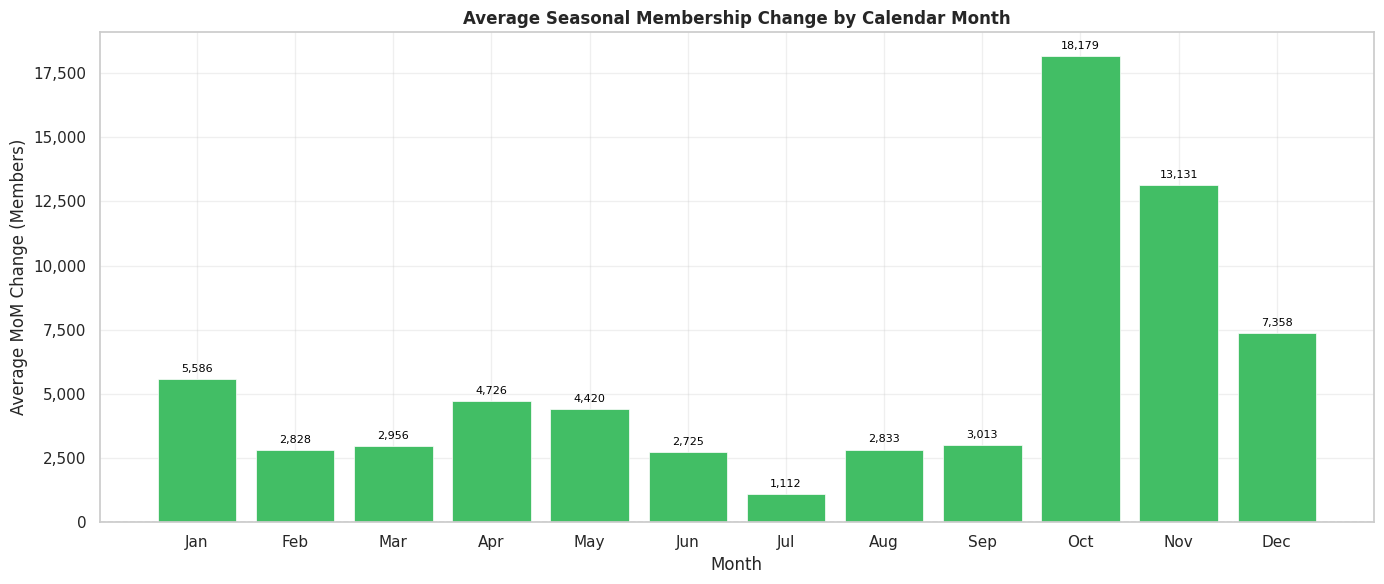

In [0]:
# ═══════════════════════════════════════════════════════════════
# 2.3 Seasonal Patterns
# ═══════════════════════════════════════════════════════════════

# Calculate average MoM change by calendar month
seasonal_pd = trend_pd.copy()
seasonal_pd["calendar_month"] = seasonal_pd["CM_snapshot_date"].dt.month
seasonal_pd["month_name"] = seasonal_pd["CM_snapshot_date"].dt.strftime("%b")

# Average MoM change by calendar month
seasonal_avg = seasonal_pd.groupby(
    ["calendar_month", "month_name"]
)["mom_change"].mean().reset_index()
seasonal_avg = seasonal_avg.sort_values("calendar_month")

# Print seasonal summary
print("Average Month-over-Month Membership Change by Calendar Month:")
print("-" * 70)
print(seasonal_avg[["month_name", "mom_change"]].to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(14, 6))

colors = [IBM_GREEN if v >= 0 else IBM_ORANGE 
          for v in seasonal_avg["mom_change"]]

bars = ax.bar(
    seasonal_avg["month_name"],
    seasonal_avg["mom_change"],
    color=colors,
    edgecolor="white",
    linewidth=0.5
)

ax.axhline(y=0, color=IBM_GRAY, linestyle="--", linewidth=1)
ax.set_title("Average Seasonal Membership Change by Calendar Month")
ax.set_xlabel("Month")
ax.set_ylabel("Average MoM Change (Members)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x:,.0f}"
))

# Add value labels on bars
for bar, val in zip(bars, seasonal_avg["mom_change"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (200 if val >= 0 else -800),
        f"{val:,.0f}",
        ha="center", va="bottom", fontsize=8, color="black"
    )

plt.tight_layout()
plt.show()

#### 2.3.1 Seasonal Patterns - Surge vs Non-Surge Comparison

Average MoM Change by Month and Period:
----------------------------------------------------------------------
month_name                 period   mom_change
       Jan Post-Surge (2024-2025) -1448.931117
       Jan       Pre-Surge (2021)          NaN
       Jan      Surge (2022-2023) 12620.249405
       Feb Post-Surge (2024-2025) -2093.230403
       Feb       Pre-Surge (2021)  2719.714964
       Feb      Surge (2022-2023)  7802.850356
       Mar Post-Surge (2024-2025)  1241.092636
       Mar       Pre-Surge (2021)  3761.876485
       Mar      Surge (2022-2023)  4268.111639
       Apr Post-Surge (2024-2025)  2774.643706
       Apr       Pre-Surge (2021)  7624.703088
       Apr      Surge (2022-2023)  5227.137767
       May Post-Surge (2024-2025)   109.857482
       May       Pre-Surge (2021)  1353.919240
       May      Surge (2022-2023) 10262.767221
       Jun Post-Surge (2024-2025)  1128.266033
       Jun       Pre-Surge (2021)  1558.788599
       Jun      Surge (2022-2023)  4904.988

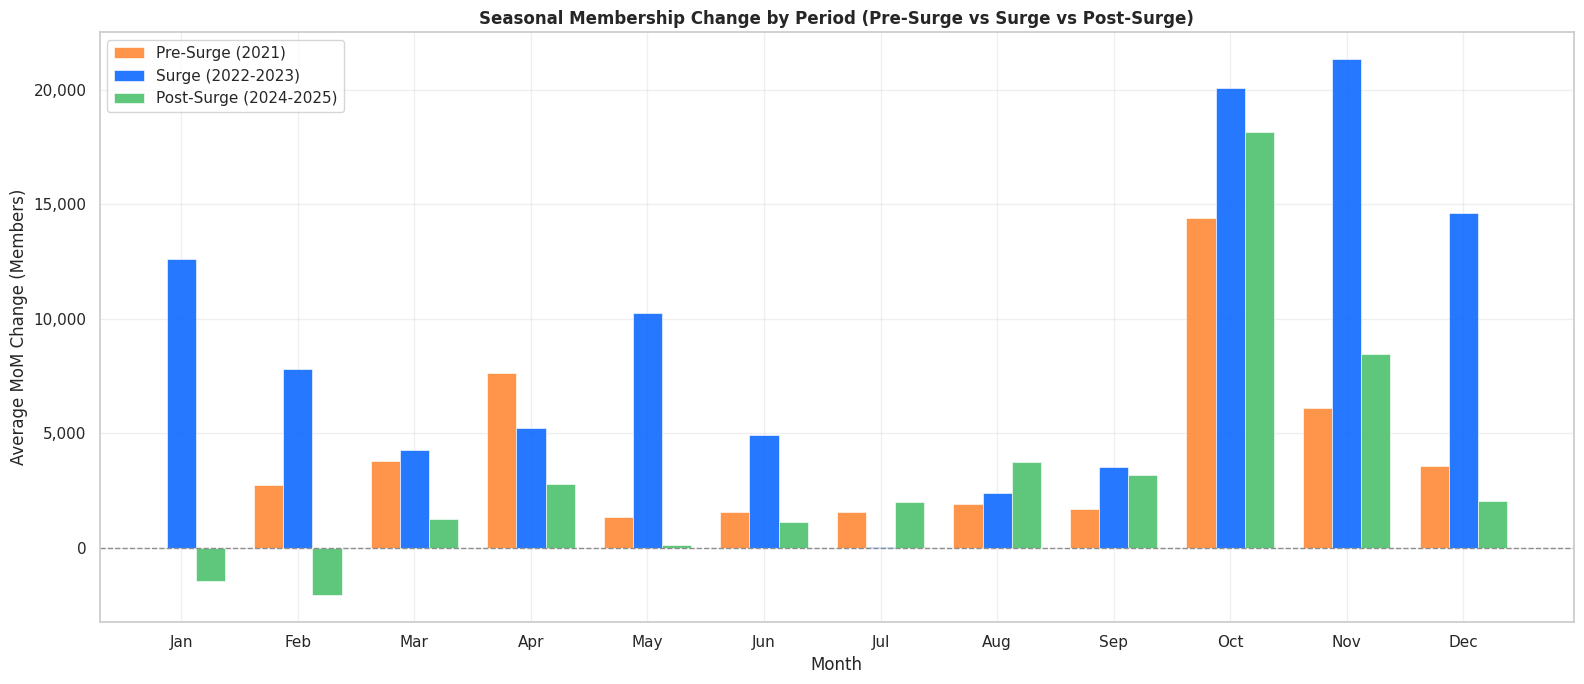

In [0]:
# ═══════════════════════════════════════════════════════════════
# 2.3.1 Seasonal Patterns - Surge vs Non-Surge Comparison
# ═══════════════════════════════════════════════════════════════

# Classify periods
seasonal_pd["period"] = seasonal_pd["CM_snapshot_date"].apply(
    lambda x: "Pre-Surge (2021)" 
    if x.year == 2021 
    else ("Surge (2022-2023)" 
    if x.year in [2022, 2023] 
    else "Post-Surge (2024-2025)")
)

# Average MoM change by calendar month and period
seasonal_period = seasonal_pd.groupby(
    ["calendar_month", "month_name", "period"]
)["mom_change"].mean().reset_index()
seasonal_period = seasonal_period.sort_values(
    ["calendar_month", "period"]
)

print("Average MoM Change by Month and Period:")
print("-" * 70)
print(seasonal_period[
    ["month_name", "period", "mom_change"]
].to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(16, 7))

periods = ["Pre-Surge (2021)", "Surge (2022-2023)", "Post-Surge (2024-2025)"]
colors_period = [IBM_ORANGE, IBM_BLUE, IBM_GREEN]
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

x = np.arange(len(months))
width = 0.25

for i, (period, color) in enumerate(zip(periods, colors_period)):
    period_data = seasonal_period[seasonal_period["period"] == period]
    period_data = period_data.sort_values("calendar_month")
    ax.bar(x + i * width, period_data["mom_change"],
           width, label=period, color=color, alpha=0.85,
           edgecolor="white", linewidth=0.5)

ax.axhline(y=0, color=IBM_GRAY, linestyle="--", linewidth=1)
ax.set_title("Seasonal Membership Change by Period (Pre-Surge vs Surge vs Post-Surge)")
ax.set_xlabel("Month")
ax.set_ylabel("Average MoM Change (Members)")
ax.set_xticks(x + width)
ax.set_xticklabels(months)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x:,.0f}"
))
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

**RESULT**

Disaggregating the seasonal pattern by period confirms that the Q4 October and November peak is a genuine structural seasonal feature rather than an artefact of the 2022 to 2023 industrial action surge. October records high average membership growth across all three periods: 14,397 pre-surge, 20,098 during the surge, and 18,150 post-surge. November follows the same pattern at 6,099, 21,339, and 8,440 respectively.

The surge period amplified the Q4 peak substantially, with October and November surge values approximately 40% higher than their pre and post-surge equivalents, consistent with the industrial action ballot commencing in October 2022 and the historic first strike in December 2022 driving exceptional membership mobilisation during that period.

Two additional findings emerge from the period comparison. January and February are negative in the post-surge period at -1,449 and -2,093 respectively, suggesting a pattern of early year membership losses not observed pre-surge, potentially reflecting non-renewal by members who joined during the industrial action period and did not maintain their membership once the dispute was resolved. April shows a notably strong pre-surge value of 7,625, consistent with the start of the NHS financial year in April and potential new staff intake at that point.

The July summer trough is confirmed as consistent across all three periods, reinforcing its status as a genuine structural seasonal feature driven by reduced administrative activity during the holiday period.

**Status:** ✓ Pass

**SUMMARY**

Seasonal analysis confirms a consistent Q4 membership growth peak across all years in the observation period, with October averaging 18,179 new members per month, the highest of any calendar month, followed by November at 13,131 and December at 7,358. All 12 calendar months record positive average membership change, confirming there is no month that consistently loses members on average. July is the weakest month at 1,112 average change, consistent with a summer administrative slowdown common in membership organisations.

The Q4 peak is consistent with the UK nursing academic calendar. Nursing degree students typically graduate in summer, with exam boards confirming results in September and October. Following exam board confirmation, universities notify the Nursing and Midwifery Council, who issue the student their NMC PIN, enabling professional registration and employment as a registered nurse. New nurses joining their first NHS post in September and October would naturally affiliate with professional membership organisations in the same period, producing the observed Q4 intake pattern. This structural seasonal driver is confirmed across all three observation periods in Section 2.3.1 above.

**Status:** ✓ Pass

### 2.4 Structural Break Investigation

**CONTEXT**

Sections 2.1 and 2.2 identified a significant structural break in membership growth beginning in October 2022, characterised by a sustained period of exceptional month-over-month gains that persisted through mid-2023 before normalising. The timing of this break coincides with the period of significant industrial action and workforce mobilisation within the UK nursing sector. A formal structural break investigation quantifies the precise boundaries of the surge period, its magnitude relative to baseline growth, and whether the post-surge membership trajectory represents a genuine new equilibrium or a gradual return to the pre-surge trend.

**PURPOSE**

To ensure:
1. The structural break is formally identified and its boundaries precisely defined
2. Pre-surge, surge, and post-surge growth rates are quantified and compared
3. The post-surge membership trajectory is assessed to determine whether a new equilibrium has been established
4. Findings provide a statistically grounded foundation for the churn hypothesis developed in Notebook 06

**STEP**

Calculate rolling average membership growth to smooth short-term fluctuations and identify the precise onset and conclusion of the structural break. Compare average monthly growth rates across the three periods. Visualise the rolling average alongside the actual membership series to clearly delineate the surge boundaries. Assess whether post-surge growth has stabilised at a new baseline or continues to decelerate.

In [0]:
# ═══════════════════════════════════════════════════════════════
# 2.4 Structural Break Investigation
# ═══════════════════════════════════════════════════════════════

# Calculate 3-month and 6-month rolling averages
trend_pd["rolling_3m"] = trend_pd["total_members"].rolling(window=3).mean()
trend_pd["rolling_6m"] = trend_pd["total_members"].rolling(window=6).mean()

# Define surge period boundaries
PRE_SURGE_END   = "2022-09-01"
SURGE_START     = "2022-10-01"
SURGE_END       = "2023-06-01"
POST_SURGE_START = "2023-07-01"

# Calculate average MoM growth by period
pre_surge  = trend_pd[trend_pd["CM_snapshot_date"] <= PRE_SURGE_END]["mom_change"].mean()
surge      = trend_pd[(trend_pd["CM_snapshot_date"] >= SURGE_START) & 
                       (trend_pd["CM_snapshot_date"] <= SURGE_END)]["mom_change"].mean()
post_surge = trend_pd[trend_pd["CM_snapshot_date"] >= POST_SURGE_START]["mom_change"].mean()

print("Average Monthly Membership Growth by Period:")
print("-" * 70)
print(f"Pre-Surge  (Jan 2021 - Sep 2022) : {pre_surge:,.0f} members/month")
print(f"Surge      (Oct 2022 - Jun 2023) : {surge:,.0f} members/month")
print(f"Post-Surge (Jul 2023 - Dec 2025) : {post_surge:,.0f} members/month")
print(f"Surge multiplier vs pre-surge    : {surge/pre_surge:.1f}x")
print("-" * 70)

# Visualisation
fig = go.Figure()

# Actual membership
fig.add_trace(go.Scatter(
    x=trend_pd["CM_snapshot_date"],
    y=trend_pd["total_members"],
    mode="lines",
    name="Total Members",
    line=dict(color=IBM_BLUE, width=1.5, dash="dot"),
    hovertemplate="<b>%{x|%b %Y}</b><br>Members: %{y:,.0f}<extra></extra>"
))

# 3-month rolling average
fig.add_trace(go.Scatter(
    x=trend_pd["CM_snapshot_date"],
    y=trend_pd["rolling_3m"],
    mode="lines",
    name="3-Month Rolling Avg",
    line=dict(color=IBM_ORANGE, width=2),
    hovertemplate="<b>%{x|%b %Y}</b><br>3M Avg: %{y:,.0f}<extra></extra>"
))

# 6-month rolling average
fig.add_trace(go.Scatter(
    x=trend_pd["CM_snapshot_date"],
    y=trend_pd["rolling_6m"],
    mode="lines",
    name="6-Month Rolling Avg",
    line=dict(color=IBM_GREEN, width=2),
    hovertemplate="<b>%{x|%b %Y}</b><br>6M Avg: %{y:,.0f}<extra></extra>"
))

# Surge period shading
fig.add_vrect(
    x0=SURGE_START, x1=SURGE_END,
    fillcolor=IBM_PURPLE, opacity=0.15,
    layer="below", line_width=0,
    annotation_text="Surge Period",
    annotation_position="top left"
)

fig.update_layout(
    title="Structural Break Analysis - Membership Growth with Rolling Averages",
    xaxis_title="Snapshot Date",
    yaxis_title="Total Members",
    template=PLOTLY_TEMPLATE,
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
    yaxis=dict(tickformat=",.0f")
)

fig.show()

Average Monthly Membership Growth by Period:
----------------------------------------------------------------------
Pre-Surge  (Jan 2021 - Sep 2022) : 2,619 members/month
Surge      (Oct 2022 - Jun 2023) : 20,016 members/month
Post-Surge (Jul 2023 - Dec 2025) : 3,541 members/month
Surge multiplier vs pre-surge    : 7.6x
----------------------------------------------------------------------


**RESULT**

The structural break investigation formally quantifies the surge period identified in Sections 2.1 and 2.2. Average monthly membership growth during the surge period of October 2022 to June 2023 reached 20,016 members per month, representing a 7.6x multiplier relative to the pre-surge baseline of 2,619 members per month. This is a statistically exceptional growth rate that would be highly unlikely to occur through organic membership acquisition alone, consistent with an event-driven mobilisation of the nursing workforce during the period of historic industrial action.

The rolling average visualisation confirms the structural break follows a classic sigmoid growth pattern. The 6-month rolling average clearly delineates three distinct phases: a flat pre-surge baseline, a steep acceleration through the shaded surge period, and a gradual deceleration into a new post-surge equilibrium. The 3-month rolling average tracks the actual series closely, confirming the surge onset was rapid rather than gradual.

The post-surge growth rate of 3,541 members per month represents a 35% uplift on the pre-surge baseline of 2,619, suggesting the organisation has retained a structural membership benefit from the surge period rather than reverting fully to its pre-surge trajectory. This is a significant finding as it implies that even accounting for potential surge-period churn, net membership remains elevated relative to the pre-2022 trend.

The 7.6x surge multiplier and the post-surge retention of elevated growth provide the quantitative foundation for the churn hypothesis to be tested in Notebook 06. Specifically, whether surge-period members exhibit materially higher churn rates than pre-surge members will determine whether the post-surge membership uplift is durable or represents a temporary elevation that will gradually normalise through attrition.

**Status:** ✓ Pass

## 3.0 Distributional Analysis

### 3.1 YoB Distribution

**CONTEXT**

The year of birth (`YoB`) distribution provides the demographic age profile of the membership base. Following the cleaning transformations in Notebook 02, `YoB` carries a 1.49% null rate with confirmed exclusions for default placeholders, age violations, and confirmed errors. The remaining valid `YoB` values span 1934 to 2008 and represent the analytically usable birth year population. Understanding the shape of this distribution reveals whether the membership skews towards older or younger cohorts, identifies any concentration risk, and establishes the age demographic context for subsequent churn analysis.

**PURPOSE**

To ensure:
1. The age demographic profile of the membership base is established
2. Skewness and concentration in the YoB distribution are identified and quantified
3. Any anomalous peaks or gaps in the distribution are documented
4. Findings inform age-band segmentation decisions in Notebook 05

**STEP**

Filter to valid `YoB` records, excluding null values and the `YOB_ELDERLY_MEMBER` and `YOB_YOUNG_MEMBER` flagged records to focus on the core analytically reliable population. Calculate summary statistics including mean, median, standard deviation, and percentile distribution. Visualise the `YoB` distribution using a histogram and overlay a kernel density estimate to reveal the underlying shape.

YoB Summary Statistics (December 2025 snapshot):
----------------------------------------------------------------------
+-------+-------+------------------+------+----------+------+------------------+-------------+
|min_YoB|max_YoB|mean_YoB          |p25   |median_YoB|p75   |std_YoB           |valid_records|
+-------+-------+------------------+------+----------+------+------------------+-------------+
|1914   |2007   |1977.7183033167378|1968.0|1978.0    |1988.0|12.957476206823268|320767       |
+-------+-------+------------------+------+----------+------+------------------+-------------+



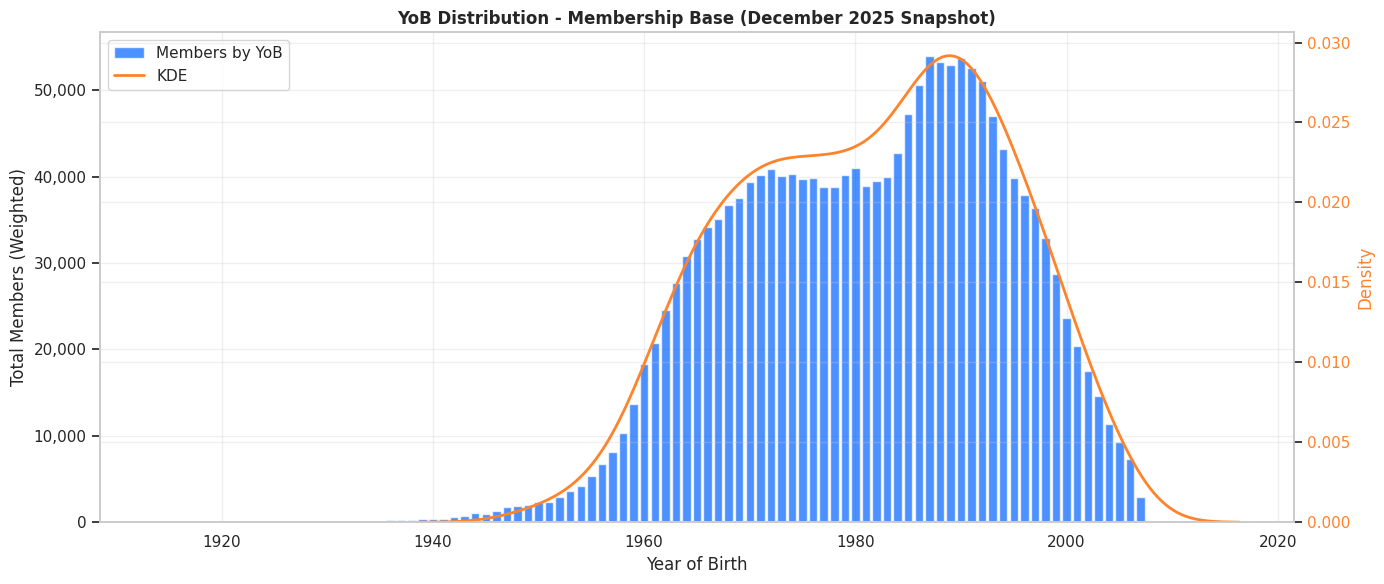

In [0]:
# ═══════════════════════════════════════════════════════════════
# 3.1 YoB Distribution
# ═══════════════════════════════════════════════════════════════

# Filter to valid YoB records excluding edge case flags
yob_df = df.filter(
    F.col("YoB").isNotNull() &
    (
        F.col("cleaning_flag").isNull() |
        ~F.col("cleaning_flag").isin(
            "YOB_ELDERLY_MEMBER", "YOB_YOUNG_MEMBER"
        )
    )
).select("YoB", "q_members_t", "CM_snapshot_date") \
 .filter(F.col("CM_snapshot_date") == "2025-12-01")

# Summary statistics
print("YoB Summary Statistics (December 2025 snapshot):")
print("-" * 70)
yob_df.select(
    F.min("YoB").alias("min_YoB"),
    F.max("YoB").alias("max_YoB"),
    F.mean("YoB").alias("mean_YoB"),
    F.expr("percentile(YoB, 0.25)").alias("p25"),
    F.expr("percentile(YoB, 0.50)").alias("median_YoB"),
    F.expr("percentile(YoB, 0.75)").alias("p75"),
    F.stddev("YoB").alias("std_YoB"),
    F.count("YoB").alias("valid_records")
).show(truncate=False)

# Convert to Pandas for visualisation
yob_pd = yob_df.groupBy("YoB") \
    .agg(F.sum("q_members_t").alias("total_members")) \
    .orderBy("YoB") \
    .toPandas()

# Visualisation
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(yob_pd["YoB"], yob_pd["total_members"],
       color=IBM_BLUE, alpha=0.7, width=0.8, label="Members by YoB")

# KDE using weighted repeated values
yob_repeated = np.repeat(
    yob_pd["YoB"].values,
    (yob_pd["total_members"] / yob_pd["total_members"].sum() * 1000).astype(int)
)

ax2 = ax.twinx()
sns.kdeplot(yob_repeated, ax=ax2, color=IBM_ORANGE,
            linewidth=2, label="KDE")
ax2.set_ylabel("Density", color=IBM_ORANGE)
ax2.tick_params(axis="y", labelcolor=IBM_ORANGE)

ax.set_title("YoB Distribution - Membership Base (December 2025 Snapshot)")
ax.set_xlabel("Year of Birth")
ax.set_ylabel("Total Members (Weighted)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x:,.0f}"
))

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

**RESULT**

The `YoB` distribution reveals a left-skewed membership age profile concentrated in the 1968 to 1988 birth year range, with 50% of members falling within this interquartile range. The distribution peaks at approximately 1988 to 1990, representing members currently aged 35 to 37 years old, the largest single age cohort in the membership base. The mean birth year of 1977.7 and median of 1978 indicate the average member is approximately 47 to 48 years old as of December 2025.

The left skew reflects a longer tail towards older birth years, consistent with a mature professional membership base where a significant proportion of members joined decades ago and remain active. The gentle decline in the right tail post-1990 reflects the natural pipeline constraint of nursing as a degree-level profession, where a three-year training period precedes NMC registration and professional membership eligibility.

The age profile carries important implications for long-term membership sustainability. The concentration of members in the 1960s and 1970s birth year cohorts represents a potential retirement wave over the coming decade, as this group approaches and reaches retirement age. Whether the organisation is recruiting younger members at a sufficient rate to offset projected retirements is a key strategic question that will be examined through cohort analysis in Notebook 05.

The small but visible pre-1940 tail represents the `YOB_ELDERLY_MEMBER` flagged cohort retained in Section 2.2 of Notebook 02, confirming their presence in the active membership base.

**Status:** ✓ Pass

### 3.2 YoJ Distribution

**CONTEXT**

The year of joining (`YoJ`) distribution reveals the tenure profile of the membership base, showing when members first joined the organisation across the observation period. Unlike `YoB`, which reflects demographic characteristics, `YoJ` directly captures membership longevity and cohort structure. Understanding the distribution of join years establishes how the membership base is composed across tenure bands, identifies periods of historically high or low recruitment, and provides the foundation for cohort-based retention analysis in Notebook 05.

**PURPOSE**

To ensure:
1. The tenure profile of the membership base is established across all active join year cohorts
2. Periods of historically high recruitment are identified and contextualised
3. The relationship between join year and the 2022 to 2023 membership surge is quantified
4. Findings inform tenure-band segmentation decisions in Notebook 05

**STEP**

Filter to valid `YoJ` records using the December 2025 snapshot to capture the most current membership composition. Calculate summary statistics including mean, median, and percentile distribution. Visualise the `YoJ` distribution using a histogram with KDE overlay, and highlight the surge period join years to quantify their contribution to the current membership base.

YoJ Summary Statistics (December 2025 snapshot):
----------------------------------------------------------------------
+-------+-------+-----------------+------+----------+------+------------------+-------------+
|min_YoJ|max_YoJ|mean_YoJ         |p25   |median_YoJ|p75   |std_YoJ           |valid_records|
+-------+-------+-----------------+------+----------+------+------------------+-------------+
|1941   |2025   |2012.545882019425|2006.0|2016.0    |2022.0|11.663791657641172|324528       |
+-------+-------+-----------------+------+----------+------+------------------+-------------+



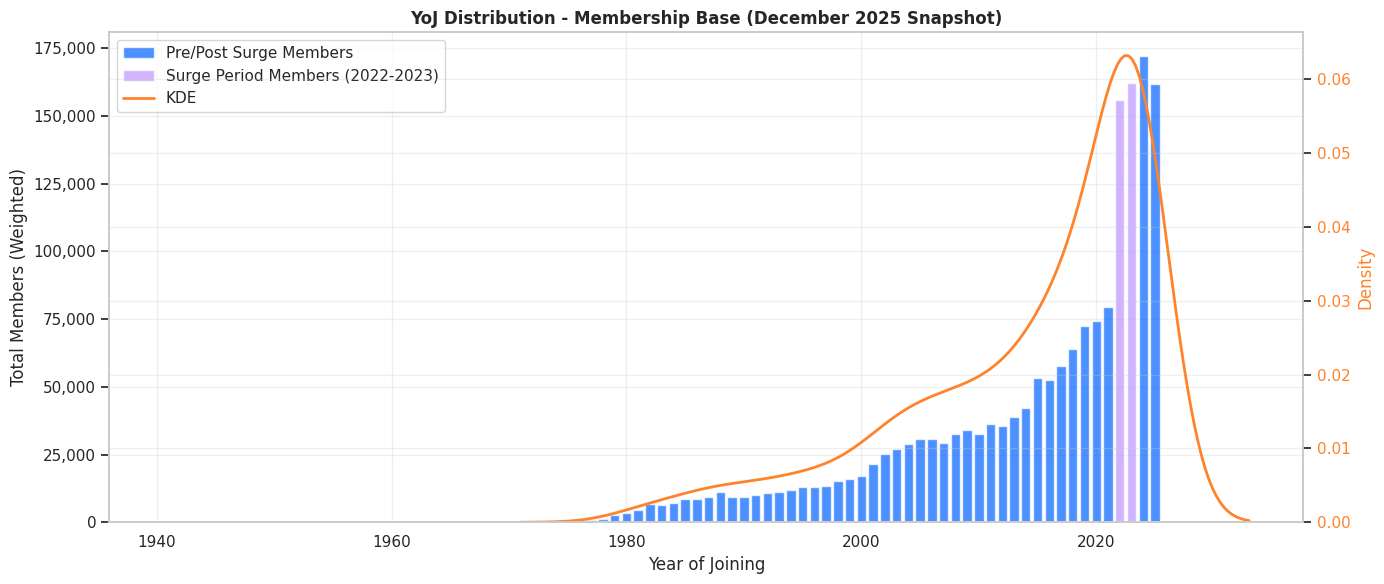

In [0]:
# ═══════════════════════════════════════════════════════════════
# 3.2 YoJ Distribution
# ═══════════════════════════════════════════════════════════════

# Filter to valid YoJ records - December 2025 snapshot
yoj_df = df.filter(
    F.col("YoJ").isNotNull() &
    (F.col("CM_snapshot_date") == "2025-12-01")
).select("YoJ", "q_members_t")

# Summary statistics
print("YoJ Summary Statistics (December 2025 snapshot):")
print("-" * 70)
yoj_df.select(
    F.min("YoJ").alias("min_YoJ"),
    F.max("YoJ").alias("max_YoJ"),
    F.mean("YoJ").alias("mean_YoJ"),
    F.expr("percentile(YoJ, 0.25)").alias("p25"),
    F.expr("percentile(YoJ, 0.50)").alias("median_YoJ"),
    F.expr("percentile(YoJ, 0.75)").alias("p75"),
    F.stddev("YoJ").alias("std_YoJ"),
    F.count("YoJ").alias("valid_records")
).show(truncate=False)

# Convert to Pandas for visualisation
yoj_pd = yoj_df.groupBy("YoJ") \
    .agg(F.sum("q_members_t").alias("total_members")) \
    .orderBy("YoJ") \
    .toPandas()

# Visualisation
fig, ax = plt.subplots(figsize=(14, 6))

# Colour bars by period
colors = [
    IBM_PURPLE if 2022 <= y <= 2023
    else IBM_BLUE
    for y in yoj_pd["YoJ"]
]

ax.bar(yoj_pd["YoJ"], yoj_pd["total_members"],
       color=colors, alpha=0.7, width=0.8)

# KDE overlay
yoj_repeated = np.repeat(
    yoj_pd["YoJ"].values,
    (yoj_pd["total_members"] / yoj_pd["total_members"].sum() * 1000).astype(int)
)

ax2 = ax.twinx()
sns.kdeplot(yoj_repeated, ax=ax2, color=IBM_ORANGE,
            linewidth=2, label="KDE")
ax2.set_ylabel("Density", color=IBM_ORANGE)
ax2.tick_params(axis="y", labelcolor=IBM_ORANGE)

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=IBM_BLUE, alpha=0.7, label="Pre/Post Surge Members"),
    Patch(facecolor=IBM_PURPLE, alpha=0.7, label="Surge Period Members (2022-2023)"),
    plt.Line2D([0], [0], color=IBM_ORANGE, linewidth=2, label="KDE")
]
ax.legend(handles=legend_elements, loc="upper left")

ax.set_title("YoJ Distribution - Membership Base (December 2025 Snapshot)")
ax.set_xlabel("Year of Joining")
ax.set_ylabel("Total Members (Weighted)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x:,.0f}"
))

plt.tight_layout()
plt.show()

**RESULT**

The `YoJ` distribution reveals a strongly right-skewed tenure profile, with membership heavily concentrated in recent join years. The median join year of 2016 confirms that half of all current members joined within the last nine years, and the 75th percentile of 2022 indicates that a quarter of the membership base joined during or after the surge period. The distribution accelerates sharply from approximately 2015 onwards, reflecting both organic membership growth and the exceptional surge period intake of 2022 to 2023.

The Kernel Density Estimate, a smoothed curve overlaid on the histogram to reveal the underlying distribution shape without bar-by-bar noise, confirms a single dominant peak around 2024 to 2025 with a long left tail extending back to 1941. This tail represents a small but persistent cohort of very long-tenured members, most likely comprising `Life Member` and joint membership categories identified in Notebook 02. Joint members hold dual professional affiliations combining their nursing membership with either the Royal College of Midwives, the University and College Union, or the Educational Institute of Scotland, consistent with members working in educational, academic, or midwifery roles alongside clinical practice.

Notably the 2024 and 2025 bars are the tallest in the distribution, exceeding even the surge period bars of 2022 and 2023. This confirms that post-surge organic recruitment has remained strong and that the organisation is continuing to attract new members at a higher rate than the pre-surge baseline, consistent with the 35% post-surge growth uplift quantified in Section 2.4.

The concentration of members in recent join years carries important implications for churn analysis. Membership bases dominated by newer members typically exhibit higher baseline churn rates, as newer members have not yet developed the loyalty and institutional attachment of long-tenured cohorts. Whether this right-skewed tenure profile contributes to elevated churn rates will be examined in Notebook 06.

**Status:** ✓ Pass

### 3.3 q_members_t Distribution

**CONTEXT**

The `q_members_t` field represents the weighted membership unit count for each cohort segment within a snapshot. As established in Notebook 01, this field uses a multiplier of approximately 2.969 rather than whole number counts, reflecting the aggregated and weighted nature of the panel dataset. Understanding the distribution of `q_members_t` across cohort segments reveals how membership is distributed across the dimensional combinations of region, category, sector, branch, and cohort variables, identifying whether membership is concentrated in a small number of large segments or spread broadly across many smaller ones.

**PURPOSE**

To ensure:
1. The distribution of membership units across cohort segments is understood
2. Concentration risk is identified, specifically whether a small number of segments dominate total membership
3. The typical segment size is established as a reference for downstream aggregation decisions
4. Any anomalous segment sizes are identified and documented

**STEP**

Using the full dataset rather than a single snapshot, calculate summary statistics for `q_members_t` at the segment level. Visualise the distribution using a log-scale histogram to handle the wide range of segment sizes, and produce a box plot to highlight the concentration of values and identify outliers.

q_members_t Summary Statistics (full dataset):
----------------------------------------------------------------------
+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+------------------+----------------+-------------+
|min              |max              |mean             |p25              |median           |p75              |p95              |p99               |std             |total_records|
+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+------------------+----------------+-------------+
|2.969121140142518|296.9121140142518|5.250934098669352|2.969121140142518|2.969121140142518|5.938242280285036|14.84560570071259|26.722090261282663|5.53513083052088|18461480     |
+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+------------------+----------------+-------

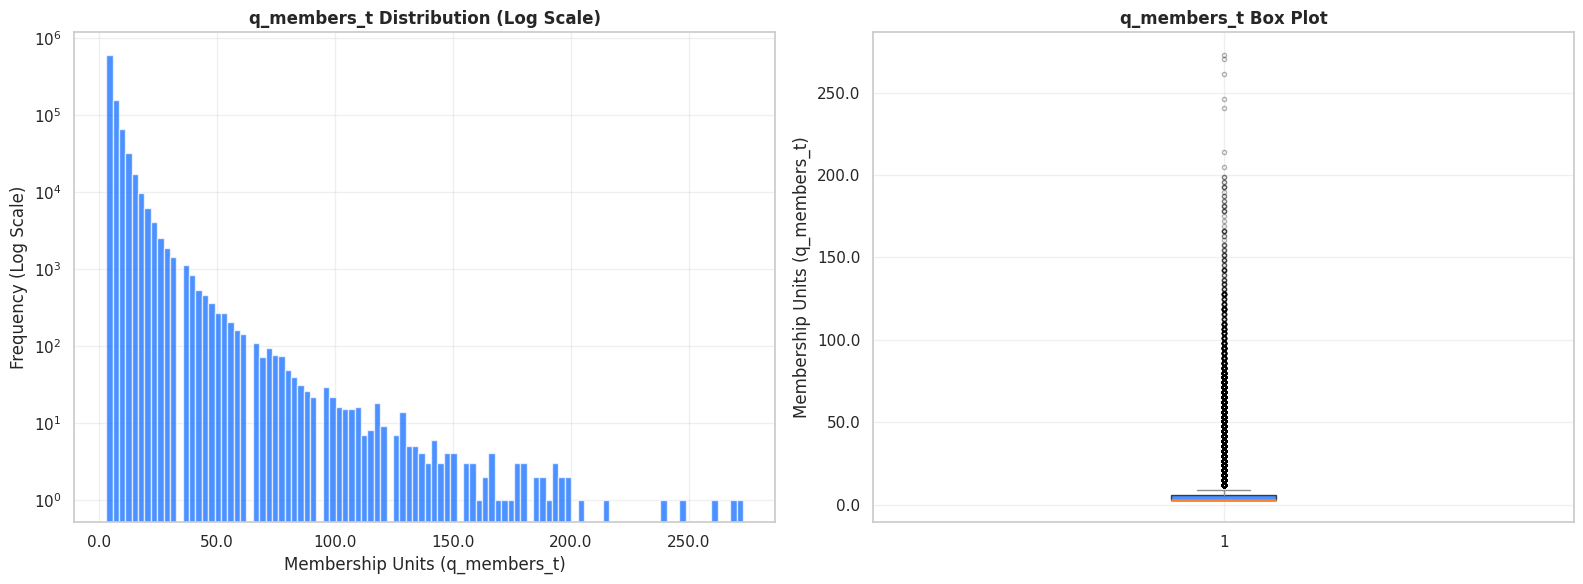

In [0]:
# ═══════════════════════════════════════════════════════════════
# 3.3 q_members_t Distribution
# ═══════════════════════════════════════════════════════════════

# Summary statistics
print("q_members_t Summary Statistics (full dataset):")
print("-" * 70)
df.select(
    F.min("q_members_t").alias("min"),
    F.max("q_members_t").alias("max"),
    F.mean("q_members_t").alias("mean"),
    F.expr("percentile(q_members_t, 0.25)").alias("p25"),
    F.expr("percentile(q_members_t, 0.50)").alias("median"),
    F.expr("percentile(q_members_t, 0.75)").alias("p75"),
    F.expr("percentile(q_members_t, 0.95)").alias("p95"),
    F.expr("percentile(q_members_t, 0.99)").alias("p99"),
    F.stddev("q_members_t").alias("std"),
    F.count("q_members_t").alias("total_records")
).show(truncate=False)

# Convert sample to Pandas for visualisation
qm_pd = df.select("q_members_t").sample(fraction=0.05, seed=42).toPandas()

# Visualisation - two panel figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left panel - log scale histogram
axes[0].hist(qm_pd["q_members_t"], bins=100,
             color=IBM_BLUE, alpha=0.7, edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_title("q_members_t Distribution (Log Scale)")
axes[0].set_xlabel("Membership Units (q_members_t)")
axes[0].set_ylabel("Frequency (Log Scale)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x:,.1f}"
))

# Right panel - box plot
axes[1].boxplot(qm_pd["q_members_t"],
                patch_artist=True,
                boxprops=dict(facecolor=IBM_BLUE, alpha=0.7),
                medianprops=dict(color=IBM_ORANGE, linewidth=2),
                whiskerprops=dict(color=IBM_GRAY),
                capprops=dict(color=IBM_GRAY),
                flierprops=dict(marker="o", color=IBM_PURPLE,
                                alpha=0.3, markersize=3))
axes[1].set_title("q_members_t Box Plot")
axes[1].set_ylabel("Membership Units (q_members_t)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x:,.1f}"
))

plt.tight_layout()
plt.show()

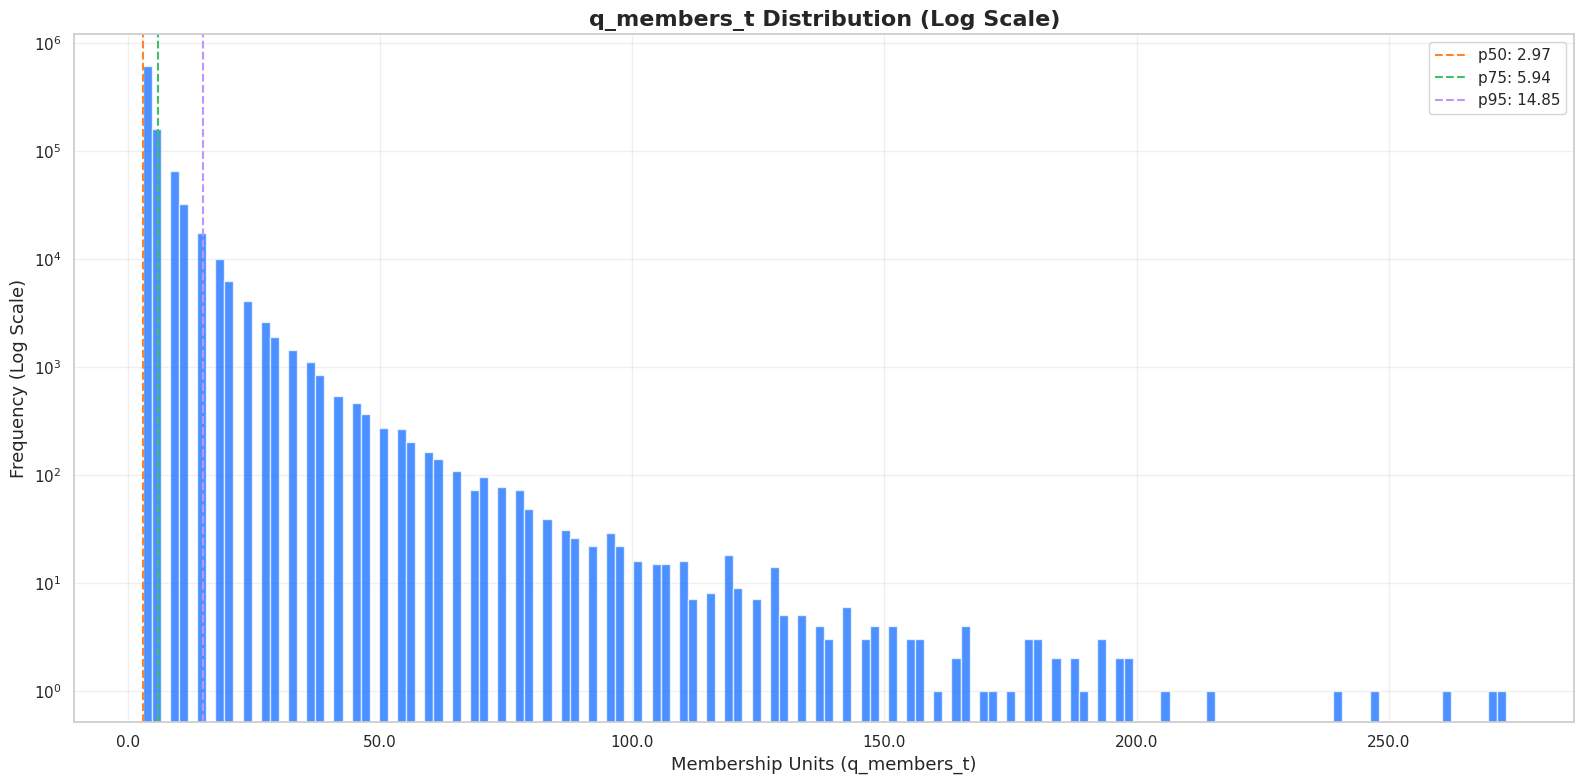

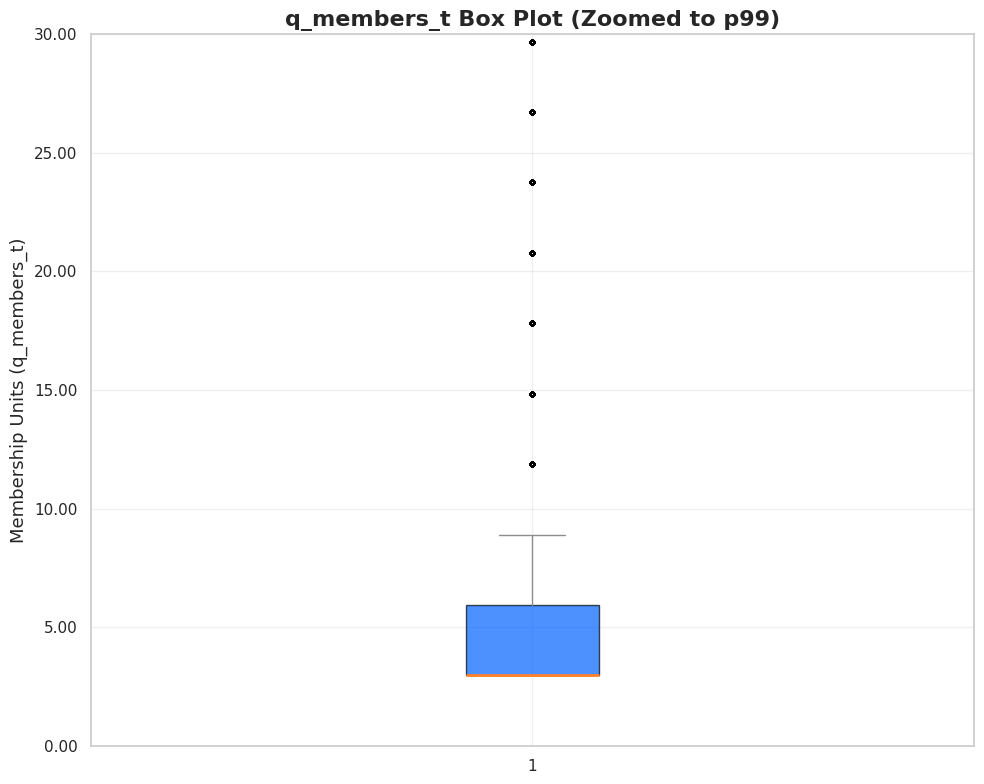

In [0]:
# ═══════════════════════════════════════════════════════════════
# 3.3 q_members_t Distribution - Enlarged Visualisation
# ═══════════════════════════════════════════════════════════════

# Left panel - log scale histogram (enlarged)
fig1, ax1 = plt.subplots(figsize=(16, 8))
ax1.hist(qm_pd["q_members_t"], bins=150,
         color=IBM_BLUE, alpha=0.7, edgecolor="white")
ax1.set_yscale("log")
ax1.set_title("q_members_t Distribution (Log Scale)", fontsize=16)
ax1.set_xlabel("Membership Units (q_members_t)", fontsize=13)
ax1.set_ylabel("Frequency (Log Scale)", fontsize=13)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x:,.1f}"
))
# Add percentile markers
for pct, val, color in [
    ("p50", 2.969, IBM_ORANGE),
    ("p75", 5.938, IBM_GREEN),
    ("p95", 14.846, IBM_PURPLE)
]:
    ax1.axvline(x=val, color=color, linestyle="--",
                linewidth=1.5, label=f"{pct}: {val:.2f}")
ax1.legend()
plt.tight_layout()
plt.show()

# Right panel - box plot zoomed to p99 (enlarged)
fig2, ax2 = plt.subplots(figsize=(10, 8))
ax2.boxplot(qm_pd["q_members_t"],
            patch_artist=True,
            boxprops=dict(facecolor=IBM_BLUE, alpha=0.7),
            medianprops=dict(color=IBM_ORANGE, linewidth=2),
            whiskerprops=dict(color=IBM_GRAY),
            capprops=dict(color=IBM_GRAY),
            flierprops=dict(marker="o", color=IBM_PURPLE,
                            alpha=0.3, markersize=3))
ax2.set_ylim(0, 30)
ax2.set_title("q_members_t Box Plot (Zoomed to p99)", fontsize=16)
ax2.set_ylabel("Membership Units (q_members_t)", fontsize=13)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x:,.2f}"
))
plt.tight_layout()
plt.show()

#### 3.3.1 Segment Concentration Analysis

In [0]:
# ═══════════════════════════════════════════════════════════════
# 3.3.1 Segment Concentration Analysis
# ═══════════════════════════════════════════════════════════════

# Top 20 largest segments by q_members_t
print("Top 20 Largest Cohort Segments:")
print("-" * 70)
df.filter(F.col("CM_snapshot_date") == "2025-12-01") \
  .select("Region", "MemCategory", "MemSectorType",
          "YoB", "YoJ", "q_members_t") \
  .orderBy(F.col("q_members_t").desc()) \
  .show(20, truncate=False)

# Concentration analysis - what % of membership do top segments hold
print("Segment Concentration Analysis:")
print("-" * 70)

total_members_dec = df.filter(
    F.col("CM_snapshot_date") == "2025-12-01"
).agg(F.sum("q_members_t")).collect()[0][0]

total_segments = df.filter(
    F.col("CM_snapshot_date") == "2025-12-01"
).count()

# Top 1% of segments
top_1pct_count = int(total_segments * 0.01)
top_1pct_members = df.filter(
    F.col("CM_snapshot_date") == "2025-12-01"
).orderBy(F.col("q_members_t").desc()) \
 .limit(top_1pct_count) \
 .agg(F.sum("q_members_t")).collect()[0][0]

# Top 10% of segments
top_10pct_count = int(total_segments * 0.10)
top_10pct_members = df.filter(
    F.col("CM_snapshot_date") == "2025-12-01"
).orderBy(F.col("q_members_t").desc()) \
 .limit(top_10pct_count) \
 .agg(F.sum("q_members_t")).collect()[0][0]

print(f"Total segments (Dec 2025)     : {total_segments:,}")
print(f"Total membership units        : {total_members_dec:,.2f}")
print("-" * 70)
print(f"Top 1% segments  ({top_1pct_count:,} segs) : "
      f"{top_1pct_members:,.2f} members "
      f"({top_1pct_members/total_members_dec*100:.1f}% of total)")
print(f"Top 10% segments ({top_10pct_count:,} segs): "
      f"{top_10pct_members:,.2f} members "
      f"({top_10pct_members/total_members_dec*100:.1f}% of total)")

Top 20 Largest Cohort Segments:
----------------------------------------------------------------------
+----------------------+------------+-------------+----+----+------------------+
|Region                |MemCategory |MemSectorType|YoB |YoJ |q_members_t       |
+----------------------+------------+-------------+----+----+------------------+
|North West            |Student     |Education    |2005|2024|225.65320665083135|
|Northern Ireland      |Student     |Education    |2006|2025|219.7149643705463 |
|Scotland              |Student     |Education    |2005|2023|184.0855106888361 |
|Yorkshire & The Humber|Student     |Education    |2005|2024|184.0855106888361 |
|Northern Ireland      |Student     |Education    |2005|2024|178.14726840855107|
|Scotland              |Nurse member|NHS          |2001|2022|178.14726840855107|
|Northern Ireland      |Student     |Education    |2005|2024|175.17814726840857|
|North West            |Student     |Education    |2006|2024|172.20902612826603|
|North

/home/spark-1c5db476-8499-4aaa-a748-11/.ipykernel/2665/command-8025538891768931-3532593706:19: DeprecationWarning:

`trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.



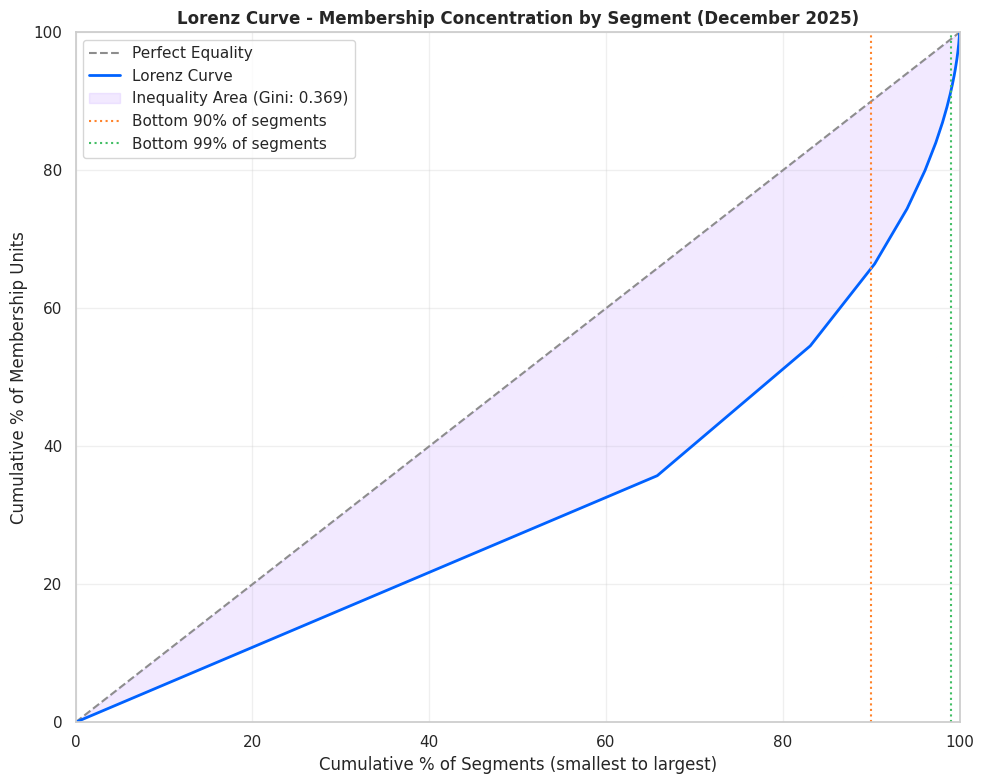

Gini Coefficient : 0.369
Interpretation   : 0 = perfect equality, 1 = maximum concentration


In [0]:
# ═══════════════════════════════════════════════════════════════
# 3.3.1 Segment Concentration Analysis - Lorenz Curve
# ═══════════════════════════════════════════════════════════════

# Get all segment membership values for December 2025
lorenz_pd = df.filter(
    F.col("CM_snapshot_date") == "2025-12-01"
).select("q_members_t") \
 .orderBy("q_members_t") \
 .toPandas()

# Calculate Lorenz curve
lorenz_pd["cumulative_members"] = lorenz_pd["q_members_t"].cumsum()
lorenz_pd["pct_segments"] = np.arange(1, len(lorenz_pd) + 1) / len(lorenz_pd) * 100
lorenz_pd["pct_members"] = lorenz_pd["cumulative_members"] / lorenz_pd["q_members_t"].sum() * 100

# Calculate Gini coefficient
n = len(lorenz_pd)
gini = 1 - 2 * np.trapz(
    lorenz_pd["pct_members"] / 100,
    lorenz_pd["pct_segments"] / 100
)

fig, ax = plt.subplots(figsize=(10, 8))

# Line of perfect equality
ax.plot([0, 100], [0, 100], color=IBM_GRAY,
        linestyle="--", linewidth=1.5, label="Perfect Equality")

# Lorenz curve
ax.plot(lorenz_pd["pct_segments"], lorenz_pd["pct_members"],
        color=IBM_BLUE, linewidth=2, label="Lorenz Curve")

# Shade the inequality area
ax.fill_between(lorenz_pd["pct_segments"],
                lorenz_pd["pct_members"],
                lorenz_pd["pct_segments"],
                alpha=0.2, color=IBM_PURPLE,
                label=f"Inequality Area (Gini: {gini:.3f})")

# Add concentration reference lines
ax.axvline(x=90, color=IBM_ORANGE, linestyle=":",
           linewidth=1.5, label="Bottom 90% of segments")
ax.axvline(x=99, color=IBM_GREEN, linestyle=":",
           linewidth=1.5, label="Bottom 99% of segments")

ax.set_title("Lorenz Curve - Membership Concentration by Segment (December 2025)")
ax.set_xlabel("Cumulative % of Segments (smallest to largest)")
ax.set_ylabel("Cumulative % of Membership Units")
ax.legend(loc="upper left")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print(f"Gini Coefficient : {gini:.3f}")
print(f"Interpretation   : 0 = perfect equality, 1 = maximum concentration")

**RESULT**

The top 20 largest cohort segments are dominated by two distinct populations. Student members in the Education sector with birth years between 2004 and 2006 and join years of 2023 to 2025 account for the majority of the largest segments, reflecting the natural density of university nursing cohorts where large groups of similarly-aged students join in the same academic intake year. The North West, Northern Ireland, Scotland, and Yorkshire and The Humber regions feature prominently, consistent with the concentration of large nursing schools in these areas. The second population comprises NHS Nurse members with join year 2022, directly confirming that the surge period created some of the largest qualified nurse segments in the dataset.

The Lorenz curve confirms moderate segment concentration with a Gini coefficient of 0.369. The bottom 90% of segments collectively hold approximately 65% of total membership, indicating that smaller segments are analytically meaningful and cannot be dismissed as noise. The top 1% of segments hold 8.6% of total membership, and the top 10% hold 34.2%, confirming that while larger segments are influential they are not dominant. A noticeable inflection in the Lorenz curve around the 60th percentile marks the point where student and surge-period NHS segments begin contributing disproportionately to cumulative membership.

**Status:** ✓ Pass

**SUMMARY**

The `q_members_t` distribution is strongly right-skewed with a power law decay shape, consistent with the granular cohort panel structure of the dataset. The median and 25th percentile both sit at exactly 2.969, the base multiplier unit, confirming that over 50% of all cohort segments represent a single member unit. The 95th percentile of 14.85 confirms that the vast majority of segments are small, while the maximum of 296.9, exactly 100 times the base multiplier, represents the largest cohort combinations in the dataset.

The concentration analysis in Section 3.3.1 confirms that the largest segments are driven by student nursing cohorts and surge-period NHS nurse members, with moderate overall concentration reflected in a Gini coefficient of 0.369. The student segment finding carries important implications for churn analysis, as students represent a structurally distinct membership category with a natural transition point at graduation when they move from student to qualified nurse membership. This student-to-nurse transition churn will be examined as a discrete churn driver in Notebook 06.

**Status:** ✓ Pass

### 3.4 q_leavers_t Distribution

**CONTEXT**

The `q_leavers_t` field records the weighted count of members leaving within each cohort segment at each snapshot. As established in Notebook 01 and confirmed in the missingness analysis of Notebook 03, `q_leavers_t` carries a 98.90% null rate by design, where null indicates an active member cohort with no leavers recorded in that period. The 1.10% of non-null records represent actual leaver events and constitute the core raw material for churn rate calculation in Notebook 06. Understanding the distribution of these non-null leaver values establishes the typical magnitude of leaver events, identifies any concentration in leaver activity, and surfaces any anomalous leaver counts that warrant investigation.

**PURPOSE**

To ensure:
1. The distribution of non-null `q_leavers_t` values is profiled and understood
2. The typical leaver event magnitude is established as a reference for Notebook 06
3. Any anomalously large leaver events are identified and their dimensional context documented
4. The temporal distribution of leaver events is assessed to identify any seasonal or structural patterns

**STEP**

Filter to non-null `q_leavers_t` records only. Calculate summary statistics for the leaver distribution. Visualise the distribution using a log-scale histogram and box plot. Examine the temporal distribution of leaver events across the 60-month observation period to identify any seasonal or structural patterns in leaver activity.

In [0]:
# ═══════════════════════════════════════════════════════════════
# 3.4 q_leavers_t Distribution
# ═══════════════════════════════════════════════════════════════

# Filter to non-null leavers only
leavers_df = df.filter(F.col("q_leavers_t").isNotNull())

# Record count confirmation
total_leaver_records = leavers_df.count()
print(f"Total non-null leaver records : {total_leaver_records:,}")
print(f"As % of total records         : {total_leaver_records/df.count()*100:.2f}%")
print("-" * 70)

# Summary statistics
print("q_leavers_t Summary Statistics:")
print("-" * 70)
leavers_df.select(
    F.min("q_leavers_t").alias("min"),
    F.max("q_leavers_t").alias("max"),
    F.mean("q_leavers_t").alias("mean"),
    F.expr("percentile(q_leavers_t, 0.25)").alias("p25"),
    F.expr("percentile(q_leavers_t, 0.50)").alias("median"),
    F.expr("percentile(q_leavers_t, 0.75)").alias("p75"),
    F.expr("percentile(q_leavers_t, 0.95)").alias("p95"),
    F.expr("percentile(q_leavers_t, 0.99)").alias("p99"),
    F.stddev("q_leavers_t").alias("std")
).show(truncate=False)

# Temporal distribution of leaver events
print("Total Leavers by Snapshot Date:")
print("-" * 70)
leavers_df.groupBy("CM_snapshot_date") \
    .agg(
        F.sum("q_leavers_t").alias("total_leavers"),
        F.count("q_leavers_t").alias("leaver_records")
    ).orderBy("CM_snapshot_date") \
    .show(60, truncate=False)

Total non-null leaver records : 202,475
As % of total records         : 1.10%
----------------------------------------------------------------------
q_leavers_t Summary Statistics:
----------------------------------------------------------------------
+-----------------+------------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+------------------+
|min              |max               |mean             |p25              |median           |p75              |p95              |p99              |std               |
+-----------------+------------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+------------------+
|2.969121140142518|50.475059382422806|3.060332072315311|2.969121140142518|2.969121140142518|2.969121140142518|2.969121140142518|5.938242280285036|0.6574978666830084|
+-----------------+------------------+-----------------+-----------------+----------

#### 3.4.1 April 2022 Leaver Anomaly Investigation

In [0]:
# ═══════════════════════════════════════════════════════════════
# 3.4.1 April 2022 Leaver Anomaly Investigation
# ═══════════════════════════════════════════════════════════════

# Check if April 2022 exists in the raw dataset at all
print("April 2022 Record Check:")
print("-" * 70)
df.filter(F.col("CM_snapshot_date") == "2022-04-01") \
  .agg(
      F.count("*").alias("total_records"),
      F.sum("q_members_t").alias("total_members"),
      F.sum("q_leavers_t").alias("total_leavers"),
      F.count("q_leavers_t").alias("non_null_leavers")
  ).show(truncate=False)

# Check surrounding months for comparison
print("Surrounding Months Leaver Comparison:")
print("-" * 70)
df.filter(
    F.col("CM_snapshot_date").isin(
        "2022-02-01", "2022-03-01", "2022-04-01",
        "2022-05-01", "2022-06-01"
    )
).groupBy("CM_snapshot_date") \
  .agg(
      F.count("*").alias("total_records"),
      F.sum("q_members_t").alias("total_members"),
      F.sum("q_leavers_t").alias("total_leavers"),
      F.count("q_leavers_t").alias("non_null_leavers")
  ).orderBy("CM_snapshot_date") \
  .show(truncate=False)

# Check if leavers are null or zero for April 2022
print("April 2022 q_leavers_t Profile:")
print("-" * 70)
df.filter(F.col("CM_snapshot_date") == "2022-04-01") \
  .groupBy("q_leavers_t") \
  .count() \
  .orderBy("q_leavers_t") \
  .show(truncate=False)

April 2022 Record Check:
----------------------------------------------------------------------
+-------------+------------------+-------------+----------------+
|total_records|total_members     |total_leavers|non_null_leavers|
+-------------+------------------+-------------+----------------+
|294946       |1478274.9406240007|NULL         |0               |
+-------------+------------------+-------------+----------------+

Surrounding Months Leaver Comparison:
----------------------------------------------------------------------
+----------------+-------------+------------------+------------------+----------------+
|CM_snapshot_date|total_records|total_members     |total_leavers     |non_null_leavers|
+----------------+-------------+------------------+------------------+----------------+
|2022-02-01      |291396       |1477220.9026191395|10626.484560569494|3459            |
|2022-03-01      |292591       |1477114.0142581237|10439.429928740517|3417            |
|2022-04-01      |294946

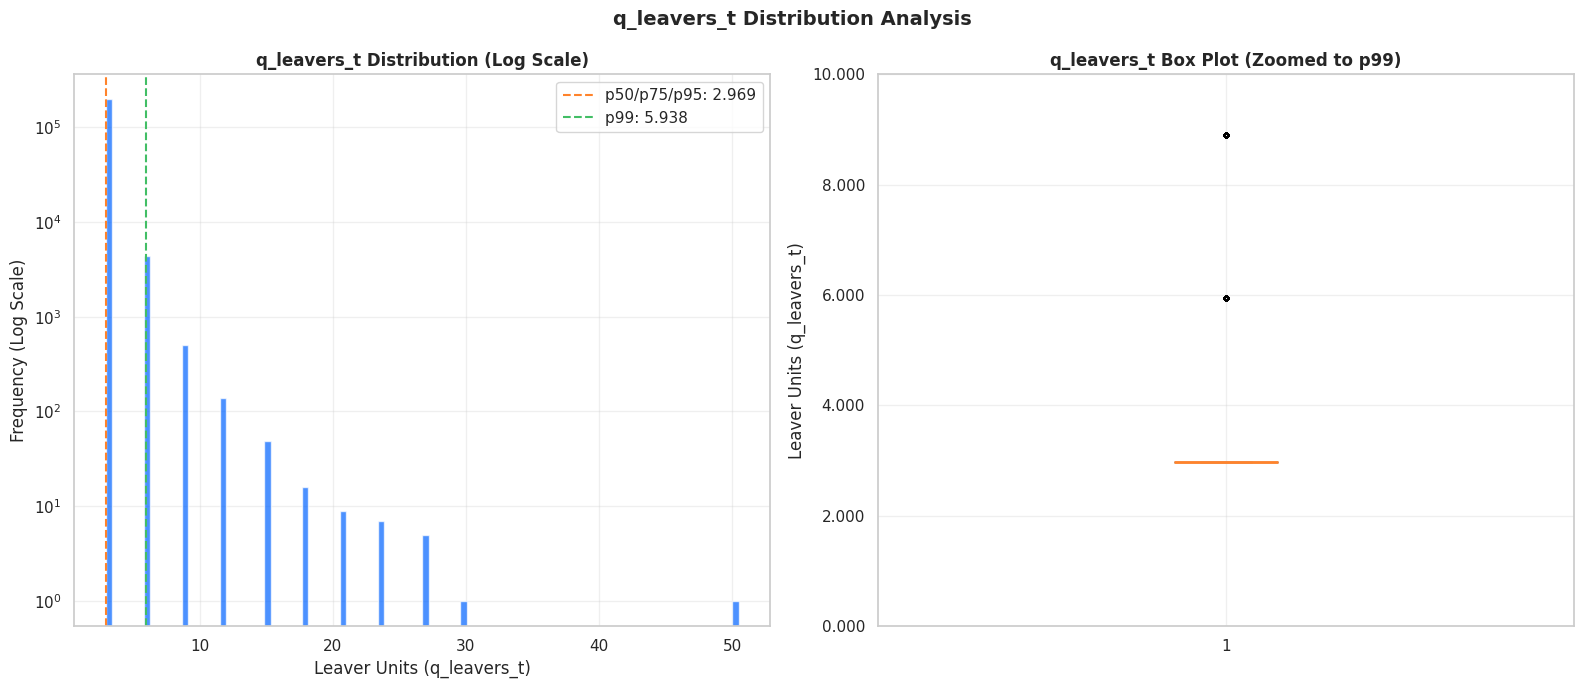

In [0]:
# ═══════════════════════════════════════════════════════════════
# 3.4 q_leavers_t Distribution - Visualisation
# ═══════════════════════════════════════════════════════════════

# Convert sample to Pandas for distribution plot
leavers_pd = leavers_df.select("q_leavers_t").toPandas()

# Temporal leaver trend
temporal_pd = leavers_df.groupBy("CM_snapshot_date") \
    .agg(F.sum("q_leavers_t").alias("total_leavers")) \
    .orderBy("CM_snapshot_date") \
    .toPandas()
temporal_pd["CM_snapshot_date"] = pd.to_datetime(
    temporal_pd["CM_snapshot_date"]
)

# ── Figure 1: Distribution (log scale histogram + box plot) ───
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left - log scale histogram
axes[0].hist(leavers_pd["q_leavers_t"], bins=100,
             color=IBM_BLUE, alpha=0.7, edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_title("q_leavers_t Distribution (Log Scale)")
axes[0].set_xlabel("Leaver Units (q_leavers_t)")
axes[0].set_ylabel("Frequency (Log Scale)")
for pct, val, color in [
    ("p50/p75/p95", 2.969, IBM_ORANGE),
    ("p99", 5.938, IBM_GREEN)
]:
    axes[0].axvline(x=val, color=color, linestyle="--",
                    linewidth=1.5, label=f"{pct}: {val:.3f}")
axes[0].legend()

# Right - box plot zoomed
axes[1].boxplot(leavers_pd["q_leavers_t"],
                patch_artist=True,
                boxprops=dict(facecolor=IBM_BLUE, alpha=0.7),
                medianprops=dict(color=IBM_ORANGE, linewidth=2),
                whiskerprops=dict(color=IBM_GRAY),
                capprops=dict(color=IBM_GRAY),
                flierprops=dict(marker="o", color=IBM_PURPLE,
                                alpha=0.3, markersize=3))
axes[1].set_ylim(0, 10)
axes[1].set_title("q_leavers_t Box Plot (Zoomed to p99)")
axes[1].set_ylabel("Leaver Units (q_leavers_t)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x:,.3f}"
))

plt.suptitle("q_leavers_t Distribution Analysis", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Figure 2: Temporal leaver trend (Plotly interactive) ──────
fig2 = go.Figure()

fig2.add_trace(go.Scatter(
    x=temporal_pd["CM_snapshot_date"],
    y=temporal_pd["total_leavers"],
    mode="lines+markers",
    name="Total Leavers",
    line=dict(color=IBM_BLUE, width=2),
    marker=dict(size=4),
    hovertemplate="<b>%{x|%b %Y}</b><br>Leavers: %{y:,.0f}<extra></extra>"
))

# Highlight January spikes
jan_pd = temporal_pd[
    temporal_pd["CM_snapshot_date"].dt.month == 1
]
fig2.add_trace(go.Scatter(
    x=jan_pd["CM_snapshot_date"],
    y=jan_pd["total_leavers"],
    mode="markers",
    name="January (Peak Month)",
    marker=dict(color=IBM_ORANGE, size=10, symbol="star"),
    hovertemplate="<b>%{x|%b %Y}</b><br>Leavers: %{y:,.0f}<extra></extra>"
))

# Flag April 2022 as missing
fig2.add_annotation(
    x="2022-04-01",
    y=0,
    text="⚠️ April 2022<br>Zero leavers<br>Compromised",
    showarrow=True,
    arrowhead=2,
    arrowcolor=IBM_ORANGE,
    font=dict(color=IBM_ORANGE, size=10),
    bgcolor="white",
    bordercolor=IBM_ORANGE
)

fig2.update_layout(
    title="Total Leavers by Snapshot Date (Jan 2021 - Nov 2025)",
    xaxis_title="Snapshot Date",
    yaxis_title="Total Leavers (Weighted)",
    template=PLOTLY_TEMPLATE,
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
    yaxis=dict(tickformat=",.0f")
)

fig2.show()

In [0]:
# ═══════════════════════════════════════════════════════════════
# 3.4 q_leavers_t Temporal Trend - Revised with April 2022 Gap
# ═══════════════════════════════════════════════════════════════

# Rebuild temporal including April 2022 with zero fill
temporal_full_pd = df.groupBy("CM_snapshot_date") \
    .agg(F.sum("q_leavers_t").alias("total_leavers")) \
    .orderBy("CM_snapshot_date") \
    .toPandas()
temporal_full_pd["CM_snapshot_date"] = pd.to_datetime(
    temporal_full_pd["CM_snapshot_date"]
)

# Fill null with zero for visualisation only
temporal_full_pd["total_leavers_viz"] = temporal_full_pd["total_leavers"].fillna(0)

# Flag April 2022
temporal_full_pd["is_compromised"] = (
    temporal_full_pd["CM_snapshot_date"] == "2022-04-01"
)

fig = go.Figure()

# Main leaver trend
fig.add_trace(go.Scatter(
    x=temporal_full_pd["CM_snapshot_date"],
    y=temporal_full_pd["total_leavers_viz"],
    mode="lines+markers",
    name="Total Leavers",
    line=dict(color=IBM_BLUE, width=2),
    marker=dict(size=4),
    hovertemplate="<b>%{x|%b %Y}</b><br>Leavers: %{y:,.0f}<extra></extra>"
))

# January spikes
jan_pd = temporal_full_pd[
    temporal_full_pd["CM_snapshot_date"].dt.month == 1
]
fig.add_trace(go.Scatter(
    x=jan_pd["CM_snapshot_date"],
    y=jan_pd["total_leavers_viz"],
    mode="markers",
    name="January (Peak Month)",
    marker=dict(color=IBM_ORANGE, size=10, symbol="star"),
    hovertemplate="<b>%{x|%b %Y}</b><br>Leavers: %{y:,.0f}<extra></extra>"
))

# April 2022 compromised point
apr22 = temporal_full_pd[temporal_full_pd["is_compromised"]]
fig.add_trace(go.Scatter(
    x=apr22["CM_snapshot_date"],
    y=apr22["total_leavers_viz"],
    mode="markers",
    name="Compromised Snapshot",
    marker=dict(color=IBM_ORANGE, size=14, 
                symbol="x", line=dict(width=2)),
    hovertemplate="<b>April 2022</b><br>⚠️ Compromised snapshot<br>Zero filled for visualisation only<extra></extra>"
))

# Annotation
fig.add_annotation(
    x="2022-04-01",
    y=500,
    text="⚠️ April 2022<br>Compromised Snapshot<br>(Zero filled for display)",
    showarrow=True,
    arrowhead=2,
    arrowcolor=IBM_ORANGE,
    font=dict(color=IBM_ORANGE, size=10),
    bgcolor="white",
    bordercolor=IBM_ORANGE,
    ay=-80
)

fig.update_layout(
    title="Total Leavers by Snapshot Date (Jan 2021 - Nov 2025)<br><sup>⚠️ April 2022 zero filled for visualisation only — excluded from analysis</sup>",
    xaxis_title="Snapshot Date",
    yaxis_title="Total Leavers (Weighted)",
    template=PLOTLY_TEMPLATE,
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
    yaxis=dict(tickformat=",.0f")
)

fig.show()

## ⚠️ DATA QUALITY FLAG — April 2022 Snapshot

**Flag:** COMPROMISED_SNAPSHOT 
**Affected Month:** April 2022 (`CM_snapshot_date = 2022-04-01`) 
**Status:** ❌ Critical

**Evidence:**
1. `q_leavers_t` is null across all 294,946 records — the only month in the 60-month observation period where zero leaver events are recorded
2. `YoB` null spike of 7,812 records identified in Notebook 03, nearly double the expected monthly null count
3. Both anomalies are isolated exclusively to April 2022 with no equivalent pattern in any surrounding month

**Conclusion:** 
April 2022 is assessed as a compromised data snapshot. The complete absence of leaver records combined with the elevated YoB missingness is consistent with a system-level data extraction or processing failure affecting this month's snapshot. The total membership count for April 2022 is consistent with surrounding months, confirming the snapshot exists but that leaver and birth year data were not correctly captured or recorded.

**Action:** 
April 2022 will be formally excluded from all churn rate calculations in Notebook 06. Any analysis involving `q_leavers_t` will document this exclusion explicitly. Membership count analysis using `q_members_t` may retain April 2022 with appropriate caveats given the membership figure appears consistent with surrounding months.

**Note — December 2025:**
December 2025 leaver records are absent from the dataset due to extraction timing. The dataset was extracted before December 2025 month-end processing was completed. This is a normal and expected data extraction characteristic, not a data quality failure, and is explicitly distinguished from the April 2022 compromised snapshot. The effective leaver observation period is January 2021 to November 2025.

**RESULT**

The `q_leavers_t` distribution profile confirms that leaver events are heavily concentrated at the base multiplier value of 2.969, with the median, 75th percentile, and 95th percentile all equal to 2.969. This confirms that the overwhelming majority of leaver events represent a single member unit departing a cohort segment in a given month. The 99th percentile of 5.938 represents two member units, and the maximum of 50.475 represents the largest single leaver event in the dataset. The standard deviation of 0.657 is extremely low relative to the mean of 3.060, further confirming the tight concentration of leaver values around the base unit.

The temporal distribution of leaver events reveals a consistent and escalating January peak across all five years of the observation period, with January totals of 11,514 in 2021, 15,199 in 2022, 12,167 in 2023, 16,110 in 2024, and 18,239 in 2025. This pattern is consistent with membership renewal cycles where annual memberships lapse at the calendar year end and non-renewals are recorded in January. The escalating January peak across successive years warrants dedicated investigation in Notebook 06 as a potential indicator of increasing churn pressure.

A critical data quality finding is the complete absence of leaver records for April 2022, the only month in the 60-month observation period where all 294,946 records carry null `q_leavers_t` values. Combined with the YoB null spike identified for the same month in Notebook 03, April 2022 is formally assessed as a compromised snapshot and will be excluded from all churn rate calculations in Notebook 06. Full details of this flag are documented in the Data Quality Flag above.

December 2025 leaver records are absent due to dataset extraction timing rather than a data quality failure, as documented in the Data Quality Flag above. The effective leaver observation period for all subsequent churn analysis is therefore January 2021 to November 2025, spanning 58 usable monthly snapshots after the exclusion of April 2022.

**Status:** ⚠️ Investigate

### 3.5 December 2025 Completeness Verification

A targeted completeness check was conducted on the December 2025 snapshot to confirm whether the absence of `q_leavers_t` records identified in Section 3.4 reflects a broader data extraction issue or is isolated to the leaver field only.

In [0]:
# ═══════════════════════════════════════════════════════════════
# December 2025 Completeness Check
# ═══════════════════════════════════════════════════════════════

print("December 2025 vs November 2025 Completeness Comparison:")
print("-" * 70)
df.filter(
    F.col("CM_snapshot_date").isin("2025-11-01", "2025-12-01")
).groupBy("CM_snapshot_date") \
  .agg(
      F.count("*").alias("total_records"),
      F.sum("q_members_t").alias("total_members"),
      F.sum("q_leavers_t").alias("total_leavers"),
      F.count("q_leavers_t").alias("non_null_leavers"),
      F.sum(F.when(F.col("YoB").isNull(), 1).otherwise(0)).alias("yob_nulls"),
      F.sum(F.when(F.col("YoJ").isNull(), 1).otherwise(0)).alias("yoj_nulls"),
      F.sum(F.when(F.col("MemSectorType").isNull(), 1).otherwise(0)).alias("sector_nulls"),
      F.countDistinct("Region").alias("distinct_regions"),
      F.countDistinct("Branch").alias("distinct_branches"),
      F.countDistinct("MemCategory").alias("distinct_categories")
  ).orderBy("CM_snapshot_date") \
  .show(truncate=False)

December 2025 vs November 2025 Completeness Comparison:
----------------------------------------------------------------------
+----------------+-------------+------------------+------------------+----------------+---------+---------+------------+----------------+-----------------+-------------------+
|CM_snapshot_date|total_records|total_members     |total_leavers     |non_null_leavers|yob_nulls|yoj_nulls|sector_nulls|distinct_regions|distinct_branches|distinct_categories|
+----------------+-------------+------------------+------------------+----------------+---------+---------+------------+----------------+-----------------+-------------------+
|2025-11-01      |325825       |1775139.5487014567|11597.387173396011|3839            |3777     |0        |24918       |13              |98               |3                  |
|2025-12-01      |324528       |1774854.513071954 |NULL              |0               |3741     |0        |24963       |13              |98               |3             

**RESULT**

The December 2025 completeness check confirms that the absence of leaver records is isolated exclusively to `q_leavers_t`. All other dimensions are complete and consistent with the November 2025 snapshot. Total membership units of 1,774,854 are virtually identical to November 2025 at 1,775,139. Region, branch, and membership category counts are identical across both months. YoB and YoJ null rates are consistent with the established dataset pattern.

December 2025 is therefore confirmed as a partial extraction affecting only leaver data, consistent with the dataset being extracted before month-end leaver processing was completed. All other analytical dimensions for December 2025 are reliable and will be retained in full for membership and segmentation analysis in subsequent notebooks.

**Status:** ✓ Pass

## 4.0 CatName Investigation

### 4.1 CatName Profile

**CONTEXT**

The `CatName` field provides a granular membership subcategory classification sitting below `MemCategory` in the organisational hierarchy. During the temporal missingness analysis in Notebook 03, a step increase in distinct `CatName` values from 14 to 16 was identified in June 2022, suggesting the introduction of two new membership subcategories at that point. A full `CatName` profile establishes the complete taxonomy of membership subcategories, their relative size, and their mapping to the three parent `MemCategory` values of Nurse member, Nurse Support Worker, and Student.

**PURPOSE**

To ensure:
1. The complete `CatName` taxonomy is documented and mapped to parent `MemCategory` values
2. The relative size of each subcategory is established across the membership base
3. The two new categories introduced in June 2022 are identified and contextualised
4. Any subcategories with analytical implications for churn analysis are flagged for Notebook 05

**STEP**

Profile all distinct `CatName` values across the full dataset, mapping each to its parent `MemCategory` and calculating total membership units and record counts. Identify which subcategories were introduced in June 2022 by comparing distinct `CatName` values before and after that date. Visualise the subcategory distribution using a horizontal bar chart to clearly show relative membership size across all categories.

In [0]:
# ═══════════════════════════════════════════════════════════════
# 4.1 CatName Profile
# ═══════════════════════════════════════════════════════════════

# Full CatName profile using December 2025 snapshot
print("CatName Profile (December 2025 Snapshot):")
print("-" * 70)
catname_pd = df.filter(
    F.col("CM_snapshot_date") == "2025-12-01"
).groupBy("CatName", "MemCategory") \
 .agg(
     F.sum("q_members_t").alias("total_members"),
     F.count("*").alias("record_count")
 ).orderBy("MemCategory", F.col("total_members").desc()) \
 .toPandas()

print(catname_pd.to_string(index=False))
print("-" * 70)
print(f"Total distinct CatName values : {catname_pd['CatName'].nunique()}")

# Pre vs post June 2022 CatName comparison
print("\nCatName values present BEFORE June 2022:")
print("-" * 70)
pre_june22 = df.filter(
    F.col("CM_snapshot_date") < "2022-06-01"
).select("CatName").distinct().toPandas()
print(sorted(pre_june22["CatName"].tolist()))

print("\nCatName values present FROM June 2022 onwards:")
print("-" * 70)
post_june22 = df.filter(
    F.col("CM_snapshot_date") >= "2022-06-01"
).select("CatName").distinct().toPandas()
print(sorted(post_june22["CatName"].tolist()))

print("\nNew CatName values introduced in June 2022:")
print("-" * 70)
new_cats = set(post_june22["CatName"].tolist()) - \
           set(pre_june22["CatName"].tolist())
print(new_cats)

CatName Profile (December 2025 Snapshot):
----------------------------------------------------------------------
                                           CatName          MemCategory  total_members  record_count
                       Nursing Support Worker Full Nurse Support Worker   1.113985e+05         26659
        Nursing Support Worker - 1st Year Discount Nurse Support Worker   3.112827e+04          6119
Nursing Support Worker - Student Nursing Associate Nurse Support Worker   7.155582e+03          2165
                  Nursing Support Worker - Retired Nurse Support Worker   4.364608e+02           147
              Nursing Support Worker -Career Break Nurse Support Worker   3.206651e+02           107
                                        Nurse Full         Nurse member   1.398622e+06        245351
                         Nurse - 1st Year Discount         Nurse member   6.596200e+04         13836
                                   Nurse - Retired         Nurse member   4.482

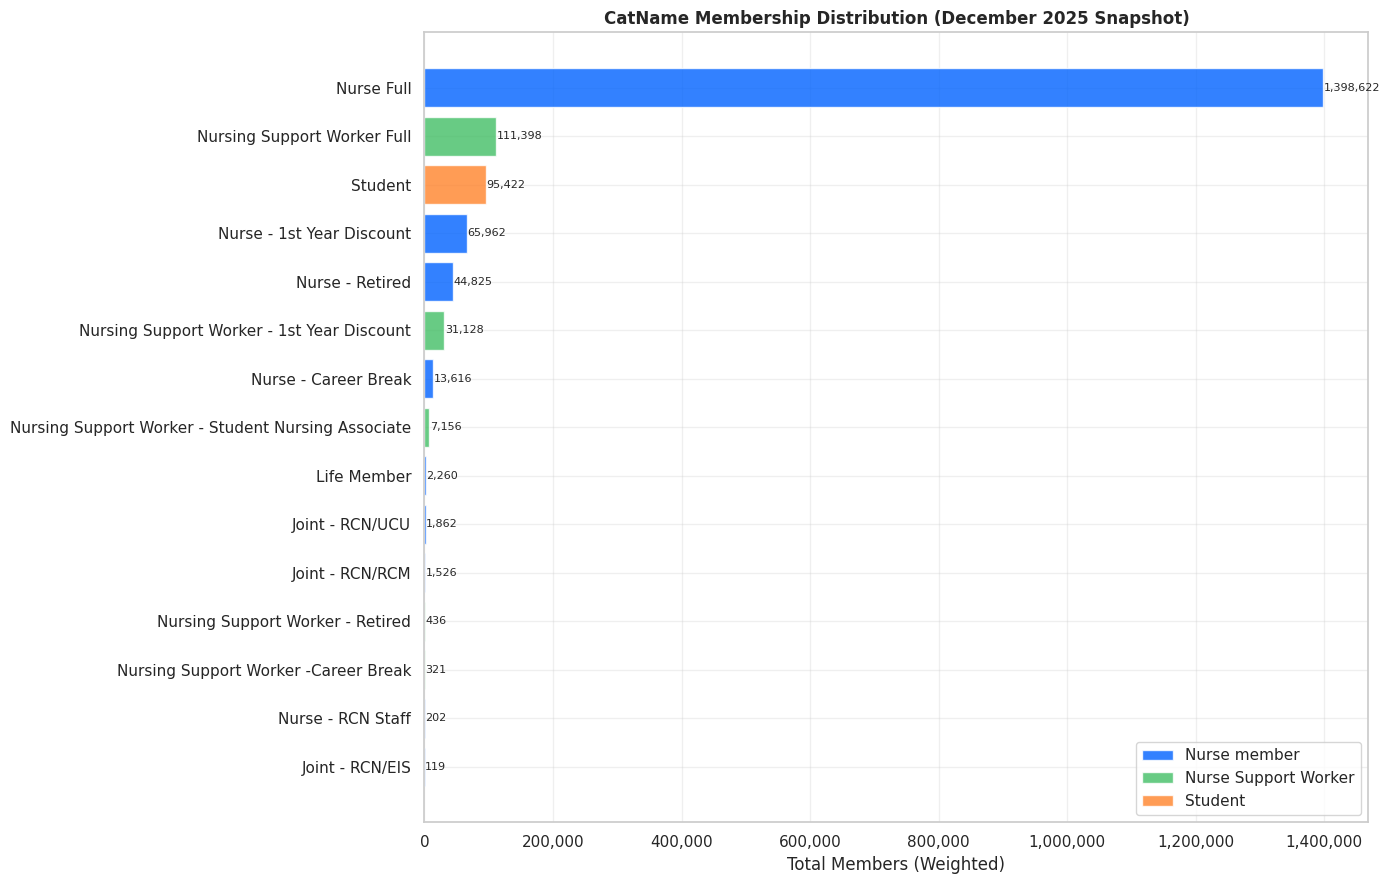

In [0]:
# ═══════════════════════════════════════════════════════════════
# 4.1 CatName Profile - Visualisation
# ═══════════════════════════════════════════════════════════════

# Sort by total members for horizontal bar chart
catname_plot = catname_pd.sort_values("total_members", ascending=True)

# Colour by MemCategory
color_map = {
    "Nurse member": IBM_BLUE,
    "Nurse Support Worker": IBM_GREEN,
    "Student": IBM_ORANGE
}
bar_colors = [color_map[cat] for cat in catname_plot["MemCategory"]]

fig, ax = plt.subplots(figsize=(14, 9))

bars = ax.barh(catname_plot["CatName"],
               catname_plot["total_members"],
               color=bar_colors, alpha=0.8, edgecolor="white")

# Add value labels
for bar, val in zip(bars, catname_plot["total_members"]):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height() / 2,
            f"{val:,.0f}", va="center", fontsize=8)

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=IBM_BLUE, alpha=0.8, label="Nurse member"),
    Patch(facecolor=IBM_GREEN, alpha=0.8, label="Nurse Support Worker"),
    Patch(facecolor=IBM_ORANGE, alpha=0.8, label="Student")
]
ax.legend(handles=legend_elements, loc="lower right")

ax.set_title("CatName Membership Distribution (December 2025 Snapshot)")
ax.set_xlabel("Total Members (Weighted)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x:,.0f}"
))

plt.tight_layout()
plt.show()

#### 4.1.1 CatName November vs December 2025 Comparison

In [0]:
# ═══════════════════════════════════════════════════════════════
# 4.1.1 CatName November vs December 2025 Comparison
# ═══════════════════════════════════════════════════════════════

print("CatName Profile Comparison - November vs December 2025:")
print("-" * 70)
df.filter(
    F.col("CM_snapshot_date").isin("2025-11-01", "2025-12-01")
).groupBy("CM_snapshot_date", "CatName", "MemCategory") \
 .agg(F.sum("q_members_t").alias("total_members")) \
 .orderBy("MemCategory", "CatName", "CM_snapshot_date") \
 .show(50, truncate=False)

# Check when Voluntary Break categories last appeared
print("Last appearance of Voluntary Break categories:")
print("-" * 70)
df.filter(
    F.col("CatName").isin(
        "Nurse - Voluntary Break",
        "Nursing Support Worker - Voluntary Break"
    )
).groupBy("CatName") \
 .agg(
     F.max("CM_snapshot_date").alias("last_snapshot"),
     F.min("CM_snapshot_date").alias("first_snapshot"),
     F.sum("q_members_t").alias("total_members")
 ).show(truncate=False)

# Check when Career Break categories first appeared
print("First appearance of Career Break categories:")
print("-" * 70)
df.filter(
    F.col("CatName").isin(
        "Nurse - Career Break",
        "Nursing Support Worker -Career Break"
    )
).groupBy("CatName") \
 .agg(
     F.min("CM_snapshot_date").alias("first_snapshot"),
     F.max("CM_snapshot_date").alias("last_snapshot"),
     F.sum("q_members_t").alias("total_members")
 ).show(truncate=False)

CatName Profile Comparison - November vs December 2025:
----------------------------------------------------------------------
+----------------+--------------------------------------------------+--------------------+------------------+
|CM_snapshot_date|CatName                                           |MemCategory         |total_members     |
+----------------+--------------------------------------------------+--------------------+------------------+
|2025-11-01      |Nursing Support Worker - 1st Year Discount        |Nurse Support Worker|32211.995249409407|
|2025-12-01      |Nursing Support Worker - 1st Year Discount        |Nurse Support Worker|31128.26603325692 |
|2025-11-01      |Nursing Support Worker - Retired                  |Nurse Support Worker|436.46080760095055|
|2025-12-01      |Nursing Support Worker - Retired                  |Nurse Support Worker|436.46080760095055|
|2025-11-01      |Nursing Support Worker - Student Nursing Associate|Nurse Support Worker|7125.89073634

#### 4.1.2 June 2022 Exact Snapshot CatName Check

In [0]:
# ═══════════════════════════════════════════════════════════════
# 4.1.2 June 2022 Exact Snapshot CatName Check
# ═══════════════════════════════════════════════════════════════

print("CatName values in May 2022 snapshot:")
print("-" * 70)
df.filter(F.col("CM_snapshot_date") == "2022-05-01") \
  .select("CatName").distinct() \
  .orderBy("CatName").show(20, truncate=False)

print("CatName values in June 2022 snapshot:")
print("-" * 70)
df.filter(F.col("CM_snapshot_date") == "2022-06-01") \
  .select("CatName").distinct() \
  .orderBy("CatName").show(20, truncate=False)

print("CatName values in July 2022 snapshot:")
print("-" * 70)
df.filter(F.col("CM_snapshot_date") == "2022-07-01") \
  .select("CatName").distinct() \
  .orderBy("CatName").show(20, truncate=False)

CatName values in May 2022 snapshot:
----------------------------------------------------------------------
+------------------------------------------+
|CatName                                   |
+------------------------------------------+
|Joint - RCN/EIS                           |
|Joint - RCN/RCM                           |
|Joint - RCN/UCU                           |
|Life Member                               |
|Nurse - 1st Year Discount                 |
|Nurse - RCN Staff                         |
|Nurse - Retired                           |
|Nurse - Voluntary Break                   |
|Nurse Full                                |
|Nursing Support Worker - 1st Year Discount|
|Nursing Support Worker - Retired          |
|Nursing Support Worker - Voluntary Break  |
|Nursing Support Worker Full               |
|Student                                   |
+------------------------------------------+

CatName values in June 2022 snapshot:
-------------------------------------------

#### 4.1.3 Nursing Support Worker - Student Nursing Associate - First Appearance Investigation

In [0]:
# ═══════════════════════════════════════════════════════════════
# 4.1.3 Nursing Support Worker - Student Nursing Associate
#        First Appearance Investigation
# ═══════════════════════════════════════════════════════════════

print("Student Nursing Associate - First and Last Appearance:")
print("-" * 70)
df.filter(
    F.col("CatName") == "Nursing Support Worker - Student Nursing Associate"
).agg(
    F.min("CM_snapshot_date").alias("first_snapshot"),
    F.max("CM_snapshot_date").alias("last_snapshot"),
    F.sum("q_members_t").alias("total_members"),
    F.count("*").alias("record_count")
).show(truncate=False)

# Check surrounding months to pinpoint introduction
print("Monthly profile around first appearance:")
print("-" * 70)
df.filter(
    F.col("CatName") == "Nursing Support Worker - Student Nursing Associate"
).groupBy("CM_snapshot_date") \
 .agg(
     F.sum("q_members_t").alias("total_members"),
     F.count("*").alias("record_count")
 ).orderBy("CM_snapshot_date") \
 .show(12, truncate=False)

Student Nursing Associate - First and Last Appearance:
----------------------------------------------------------------------
+--------------+-------------+-----------------+------------+
|first_snapshot|last_snapshot|total_members    |record_count|
+--------------+-------------+-----------------+------------+
|2025-02-01    |2025-12-01   |60804.63182899474|18445       |
+--------------+-------------+-----------------+------------+

Monthly profile around first appearance:
----------------------------------------------------------------------
+----------------+------------------+------------+
|CM_snapshot_date|total_members     |record_count|
+----------------+------------------+------------+
|2025-02-01      |38.59857482185274 |13          |
|2025-03-01      |510.6888361045138 |166         |
|2025-04-01      |6048.099762470062 |1843        |
|2025-05-01      |6318.289786223016 |1919        |
|2025-06-01      |6440.023752968852 |1955        |
|2025-07-01      |6576.603325415398 |1994  

**RESULT**

The CatName taxonomy comprises 15 active subcategories in the December 2025 snapshot, mapping across three parent membership categories. `Nurse Full` dominates the membership base at 1,398,622 weighted members, representing 78.8% of total membership and confirming that aggregate churn metrics will be overwhelmingly driven by this single subcategory. The next largest categories are `Nursing Support Worker Full` at 111,398 and `Student` at 95,422, broadly comparable in size but representing structurally distinct membership populations with different career trajectories and retention drivers.

The CatName taxonomy has evolved across the observation period through three distinct changes. In June 2022, two new Career Break subcategories were introduced — `Nurse - Career Break` and `Nursing Support Worker - Career Break` — initially coexisting with the pre-existing Voluntary Break variants before fully replacing them by May 2023, confirming a deliberate terminology standardisation rather than a new membership offering. This transition aligns with the broader pattern of incremental system modernisation identified across the observation period. In February 2025, `Nursing Support Worker - Student Nursing Associate` was introduced through a gradual progressive rollout, growing from 13 records in February 2025 to 2,165 by December 2025, representing a genuinely new membership pathway for nursing associates rather than a rename or migration.

Two subcategories carry particular significance for churn analysis. `Nurse - 1st Year Discount` at 65,962 members represents newly qualified nurses in their transition year, a cohort with a natural renewal decision point at the end of their discounted period. `Student` at 95,422 members represents a structurally distinct population with a guaranteed transition point at graduation, where members either upgrade to a qualified nurse category or lapse entirely. Both cohorts will be examined as discrete churn risk segments in Notebook 06.

**Status:** ✓ Pass

### 4.2 June 2022 New Category Investigation

**CONTEXT**

The CatName profile in Section 4.1 confirmed that June 2022 saw the introduction of two new Career Break subcategories alongside the existing Voluntary Break variants, with the Voluntary Break categories subsequently phased out by May 2023. Understanding the transition between these categories in detail establishes whether members were migrated from Voluntary Break to Career Break in a single batch event or whether the transition was gradual, and whether the Career Break and Voluntary Break categories represent the same underlying membership population or distinct cohorts.

**PURPOSE**

To ensure:
1. The transition from Voluntary Break to Career Break is precisely characterised as batch or gradual
2. Whether members were directly migrated or independently reclassified is established
3. The overlap period where both categories coexisted is quantified
4. Findings inform how Career Break and Voluntary Break records should be treated as a unified category in downstream churn analysis

**STEP**

Track the monthly membership totals for all four transitioning categories — `Nurse - Voluntary Break`, `Nurse - Career Break`, `Nursing Support Worker - Voluntary Break`, and `Nursing Support Worker - Career Break` — across the full observation period. Visualise the transition to identify whether it was a clean batch migration or a gradual overlap. Quantify the combined membership across both categories at each point in time to confirm whether total Career Break membership is consistent before and after the transition.

In [0]:
# ═══════════════════════════════════════════════════════════════
# 4.2 June 2022 New Category Investigation
# ═══════════════════════════════════════════════════════════════

# Track all four transitioning categories over time
transition_pd = df.filter(
    F.col("CatName").isin(
        "Nurse - Voluntary Break",
        "Nurse - Career Break",
        "Nursing Support Worker - Voluntary Break",
        "Nursing Support Worker -Career Break"
    )
).groupBy("CM_snapshot_date", "CatName") \
 .agg(F.sum("q_members_t").alias("total_members")) \
 .orderBy("CM_snapshot_date", "CatName") \
 .toPandas()

transition_pd["CM_snapshot_date"] = pd.to_datetime(
    transition_pd["CM_snapshot_date"]
)

print("Voluntary Break vs Career Break Transition:")
print("-" * 70)
print(transition_pd.to_string(index=False))

# Visualisation
fig = go.Figure()

categories = [
    ("Nurse - Voluntary Break", IBM_ORANGE, "dash"),
    ("Nurse - Career Break", IBM_BLUE, "solid"),
    ("Nursing Support Worker - Voluntary Break", IBM_GREEN, "dash"),
    ("Nursing Support Worker -Career Break", IBM_PURPLE, "solid")
]

for cat, color, dash in categories:
    cat_data = transition_pd[transition_pd["CatName"] == cat]
    fig.add_trace(go.Scatter(
        x=cat_data["CM_snapshot_date"],
        y=cat_data["total_members"],
        mode="lines+markers",
        name=cat,
        line=dict(color=color, width=2, dash=dash),
        marker=dict(size=4),
        hovertemplate=f"<b>{cat}</b><br>%{{x|%b %Y}}<br>Members: %{{y:,.0f}}<extra></extra>"
    ))

# Mark transition period
fig.add_vrect(
    x0="2022-06-01", x1="2023-05-01",
    fillcolor=IBM_GRAY, opacity=0.1,
    layer="below", line_width=0,
    annotation_text="Transition Period",
    annotation_position="top left"
)

fig.update_layout(
    title="Voluntary Break to Career Break Transition (2021-2025)",
    xaxis_title="Snapshot Date",
    yaxis_title="Total Members (Weighted)",
    template=PLOTLY_TEMPLATE,
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
    yaxis=dict(tickformat=",.0f")
)

fig.show()

Voluntary Break vs Career Break Transition:
----------------------------------------------------------------------
CM_snapshot_date                                  CatName  total_members
      2021-01-01                  Nurse - Voluntary Break     326.603325
      2021-01-01 Nursing Support Worker - Voluntary Break       5.938242
      2021-02-01                  Nurse - Voluntary Break     317.695962
      2021-02-01 Nursing Support Worker - Voluntary Break       5.938242
      2021-03-01                  Nurse - Voluntary Break     314.726841
      2021-03-01 Nursing Support Worker - Voluntary Break       5.938242
      2021-04-01                  Nurse - Voluntary Break     317.695962
      2021-04-01 Nursing Support Worker - Voluntary Break       8.907363
      2021-05-01                  Nurse - Voluntary Break     317.695962
      2021-05-01 Nursing Support Worker - Voluntary Break       8.907363
      2021-06-01                  Nurse - Voluntary Break     305.819477
      202

**RESULT**

The transition from Voluntary Break to Career Break categories is confirmed as a gradual progressive reclassification rather than a batch migration event. Both category pairs coexisted throughout the 12-month transition period from June 2022 to May 2023, with Voluntary Break membership declining steadily as Career Break membership grew correspondingly. `Nurse - Voluntary Break` declined from a peak of approximately 321 members in June 2022 to 18 by May 2023 before disappearing entirely in June 2023. `Nursing Support Worker - Voluntary Break` followed a similar pattern, reaching zero by January 2023.

The gradual transition pattern confirms that members were individually reclassified as they interacted with the membership system during the transition period, rather than being administratively migrated in a single operation. This is consistent with the broader pattern of incremental system modernisation identified across the observation period.

Notably `Nurse - Career Break` continued growing strongly beyond the transition period, reaching 13,616 members by December 2025 compared to a maximum of approximately 321 Voluntary Break members prior to June 2022. This 42-fold increase confirms that the Career Break category attracted a substantially larger membership population than its Voluntary Break predecessor, suggesting either a broader eligibility criterion, improved member awareness, or genuine growth in career break activity within the nursing workforce consistent with post-pandemic workforce patterns.

For downstream churn analysis in Notebook 06, Voluntary Break and Career Break records will be treated as a unified Career Break population given the confirmed terminology equivalence, with the transition period noted as a classification artefact rather than genuine membership movement.

**Status:** ✓ Pass

### 4.3 CatName to MemCategory Hierarchy Validation

**CONTEXT**

The `CatName` field sits below `MemCategory` in the organisational membership hierarchy, providing granular subcategory classification within each of the three parent categories of Nurse member, Nurse Support Worker, and Student. The CatName profile in Section 4.1 revealed the expected mapping between subcategories and their parent categories. A formal hierarchy validation confirms that no `CatName` values are incorrectly mapped to the wrong parent `MemCategory`, that the hierarchy is stable across the full 60-month observation period, and that no orphaned or ambiguous mappings exist that could distort segmentation analysis in Notebook 05.

**PURPOSE**

To ensure:
1. Every CatName value maps to exactly one parent MemCategory value with no cross-category contamination
2. The hierarchy mapping is consistent across all 60 snapshot dates
3. No orphaned CatName values exist without a valid parent MemCategory
4. The validated hierarchy is documented as a reference for all downstream segmentation analysis

**STEP**

For each distinct CatName value, identify all distinct MemCategory values it maps to across the full dataset. Any CatName mapping to more than one MemCategory indicates a hierarchy violation. Confirm that all CatName values have a valid non-null MemCategory parent and that the mapping is consistent across all snapshot dates.

In [0]:
# ═══════════════════════════════════════════════════════════════
# 4.3 CatName to MemCategory Hierarchy Validation
# ═══════════════════════════════════════════════════════════════

# Check each CatName maps to exactly one MemCategory
print("CatName to MemCategory Mapping Validation:")
print("-" * 70)
hierarchy_check = df.groupBy("CatName") \
    .agg(
        F.countDistinct("MemCategory").alias("distinct_memcategory"),
        F.collect_set("MemCategory").alias("memcategory_values")
    ).orderBy("CatName")

hierarchy_check.show(20, truncate=False)

# Flag any violations
violations = hierarchy_check.filter(
    F.col("distinct_memcategory") > 1
)
violation_count = violations.count()
print(f"Hierarchy violations found: {violation_count}")

if violation_count > 0:
    print("Violation details:")
    violations.show(truncate=False)
else:
    print("✓ All CatName values map to exactly one MemCategory")

# Confirm no null MemCategory for any CatName
print("\nNull MemCategory Check:")
print("-" * 70)
null_check = df.filter(F.col("MemCategory").isNull()).count()
print(f"Records with null MemCategory: {null_check:,}")

# Confirm hierarchy stability across all snapshots
print("\nHierarchy Stability Check (sample of 5 snapshots):")
print("-" * 70)
df.filter(
    F.col("CM_snapshot_date").isin(
        "2021-01-01", "2022-06-01", "2023-01-01",
        "2024-01-01", "2025-12-01"
    )
).groupBy("CM_snapshot_date") \
 .agg(
     F.countDistinct("CatName").alias("distinct_catnames"),
     F.countDistinct("MemCategory").alias("distinct_memcategories")
 ).orderBy("CM_snapshot_date") \
 .show(truncate=False)

CatName to MemCategory Mapping Validation:
----------------------------------------------------------------------
+--------------------------------------------------+--------------------+----------------------+
|CatName                                           |distinct_memcategory|memcategory_values    |
+--------------------------------------------------+--------------------+----------------------+
|Joint - RCN/EIS                                   |1                   |[Nurse member]        |
|Joint - RCN/RCM                                   |1                   |[Nurse member]        |
|Joint - RCN/UCU                                   |1                   |[Nurse member]        |
|Life Member                                       |1                   |[Nurse member]        |
|Nurse - 1st Year Discount                         |1                   |[Nurse member]        |
|Nurse - Career Break                              |1                   |[Nurse member]        |
|Nurse - RCN 

**RESULT**

The CatName to MemCategory hierarchy validation confirms a perfectly clean and consistent mapping across the full dataset. All 17 distinct CatName values map to exactly one parent MemCategory with zero violations, zero null MemCategory records, and no orphaned or ambiguous mappings. The three parent categories of Nurse member, Nurse Support Worker, and Student each retain a stable and exclusive set of subcategories throughout the observation period.

The hierarchy stability check confirms that the three parent MemCategory values remain constant across all 60 snapshot dates, while the distinct CatName count varies between 14 and 16 reflecting the category introductions and phase-outs documented in Sections 4.1 and 4.2. The 2023 snapshot showing 15 distinct CatNames reflects the mid-transition state where Nurse - Voluntary Break was still present but Nursing Support Worker - Voluntary Break had already been phased out.

The validated hierarchy provides a reliable foundation for all downstream segmentation analysis in Notebook 05. CatName and MemCategory can be used interchangeably as analytical dimensions with confidence that no cross-category contamination exists, and the documented category transitions provide the necessary context for interpreting any time-series analysis that spans the June 2022 and May 2023 transition boundaries.

**Status:** ✓ Pass

## 5.0 Summary & Conclusions

### 5.1 EDA Part 1 Summary

**SUMMARY**

Notebook 04 conducted a comprehensive first-phase exploratory data analysis across four analytical domains; temporal dynamics, distributional profiling, and membership taxonomy establishing the foundational analytical context for all subsequent notebooks.

The temporal analysis confirmed a 23.59% net membership growth across the 60-month observation period from 1,436,113 in January 2021 to 1,774,855 in December 2025. Four distinct growth phases were identified and quantified: steady post-pandemic recovery in 2021, a plateau and slight decline in early 2022, an exceptional surge period from October 2022 through mid-2023 producing a 7.6x growth multiplier relative to the pre-surge baseline, and a stabilisation phase from mid-2023 onwards settling at a post-surge equilibrium approximately 35% above the pre-surge growth rate. The surge period coincides with a period of significant industrial action and workforce mobilisation within the UK nursing sector, explored in detail in the analysis findings chapter. Seasonal analysis confirmed a genuine Q4 October and November membership growth peak driven by the UK nursing academic calendar, with newly qualified nurses completing NMC registration following summer graduation. A consistent and escalating January leaver peak was identified across all five years, consistent with annual membership renewal cycles.

The distributional analysis established that the membership base has a mean birth year of 1977.7, representing an average member age of approximately 47 to 48 years, with a concentration of members in the 1968 to 1988 birth year range. The year of joining distribution is strongly right-skewed with a median join year of 2016, confirming a predominantly recent membership base. The q_members_t distribution follows a power law decay with moderate segment concentration confirmed by a Gini coefficient of 0.369. The largest segments are dominated by Student members in Education sector cohorts and NHS Nurse members with join year 2022. The q_leavers_t analysis identified a critical data quality finding in the form of a compromised April 2022 snapshot carrying zero leaver records across all 294,946 rows, formally flagged for exclusion from all churn rate calculations in Notebook 06. The effective leaver observation period is confirmed as January 2021 to November 2025 spanning 58 usable monthly snapshots.

The CatName taxonomy investigation confirmed 17 distinct subcategories across the observation period mapping cleanly to three parent MemCategory values with zero hierarchy violations. The June 2022 introduction of Career Break categories and their gradual replacement of Voluntary Break variants over a 12-month transition period was characterised as incremental system modernisation. The February 2025 introduction of Nursing Support Worker - Student Nursing Associate was confirmed as a genuinely new membership pathway. The hierarchy validation provides a reliable foundation for segmentation analysis in Notebook 05.

### 5.2 Next Steps

Notebook 05: Exploratory Data Analysis Part 2 will build directly on the foundational findings established in this notebook. The following analytical workstreams are planned:

**Segmentation Analysis**
Profile membership composition across all key dimensions including region, membership category, sector type, and the validated CatName taxonomy. Identify which segments are growing, stable, or declining across the observation period and quantify their relative contribution to total membership.

**Cohort Analysis**
Examine membership retention and growth patterns by join year cohort, with particular focus on whether surge-period cohorts (YoJ 2022-2023) exhibit different retention trajectories to pre-surge cohorts. The right-skewed YoJ distribution and concentration of recent joiners established in Section 3.2 provides the foundation for this analysis.

**Age Band Analysis**
Convert the YoB distribution established in Section 3.1 into analytical age bands and profile membership composition and growth trends by age group. Assess whether the organisation is recruiting sufficient younger members to offset the projected retirement wave in the 1960s and 1970s birth year cohorts.

**Regional Analysis**
Profile membership distribution and growth trends across all 13 regions, identifying geographic concentration risk and regional variation in membership dynamics. The North West dominance in student segments identified in Section 3.3.1 will be examined in a broader regional context.

**Churn Precursor Indicators**
Develop preliminary churn precursor metrics including segment-level leaver rates and tenure-based attrition patterns, establishing the analytical groundwork for the formal churn rate calculations in Notebook 06.

### Run Metadata

**Notebook:** 04 - Exploratory Data Analysis Part 1 
**Author:** D. 
**Executed:** {RUN_TS} 
**Dataset:** churn_t_db.csv (18,461,480 rows, 14 columns) 
**Source:** Silver table at /Volumes/workspace/rcn_churn/silver/churn_cleaned/ 
**Exclusions:** April 2022 (compromised snapshot), December 2025 (no leaver data) 
**Status:** ✓ Complete

In [0]:
# ═══════════════════════════════════════════════════════════════
# Notebook 04 Complete
# ═══════════════════════════════════════════════════════════════

from datetime import datetime
RUN_TS = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

print("=" * 70)
print("Notebook 04: Exploratory Data Analysis Part 1")
print("=" * 70)
print(f"Status    : Complete")
print(f"Executed  : {RUN_TS}")
print("=" * 70)

Notebook 04: Exploratory Data Analysis Part 1
Status    : Complete
Executed  : 2026-03-12 16:13:10
